# Group Project 2: Data Structures in Action - Table of Contents & Text Analysis


**Authors:** *Mike Beitner, Luis Echeverry, & Christopher Taylor*

**Sources**
- Data Science/Machine Learning Book:

    *Math for Deep Learning - Ronald T. Kneusel*
    - Link: (https://cbwilp-artefacts.s3.ap-south-1.amazonaws.com/AIML/SEM2/FREE_BOOKS/Ronald_T_Kneusel_Math_for_Deep_Learning_What_You_Need_to_Know_to.pdf)
- Public Domain Novel:

    *The Brothers Karamazov - Fyodor Dostoevsky (tr. Constance Garnett)*
    - Link: (https://www.gutenberg.org/files/28054/28054-0.txt)

---

## Project Overview




This project analyzes large text datasets using various data structures and algorithms. We extracted our text datasets from two separate sources: a Data Science or Machine Learning (DS/ML) book & a public domain novel. Using these two text sources, we:
1. Create a hierarchical Table of Contents (TOC) for our DS/ML book
2. Conduct a letter & word analysis for our public domain novel with no use of NLP libraries

The Project is organized into 2 main sections:
- **Section 1**
    - Builds a **hierarchical tree** from the TOC of a DS/ML book using Python. Implements insert(), print_toc() in three modes, depth(), and height().
- **Section 2**
    - Analyzes a public-domain novel from Project Gutenberg across two workstreams:
        - **Data Processing:** Preprocessing pipeline, letter/word frequency, n-grams, and sentence metrics
        - **Visualizations & Insights:** Visualizations that include bar plots, word clouds, and tables. Also including a Big-O algorithmic complexity analysis for our work.




---

## Setup & Imports

In [ ]:
# ENVIRONMENT SETUP (DEPENDENCY MANAGEMENT)
# INSTALLING EXTERNAL PACKAGE: WORDCLOUD
# "--quiet" REDUCES TERMINAL NOISE FOR CLEANER NOTEBOOK OUTPUT
# WHY:
# 1. GUARANTEES REPRODUCIBILITY ACROSS DIFFERENT MACHINES / RUNTIMES
# 2.  PREVENTS IMPORT FAILURES LATER IN THE PIPELINE
!pip install wordcloud --quiet
# IMPORTING NLTK LIBRARY FOR NATURAL LANGUAGE PROCESSING UTILITIES
import nltk
# DOWNLOADING STOPWORDS CORPUS FROM NLTK
# STOPWORDS ARE HIGH-FREQUENCY, LOW-INFORMATION WORDS (THE, AND, BUT, ...)
# "quiet=True" SUPPRESSES DOWNLOAD LOG OUTPUT
# WHY:
# 1. STOPWORD REMOVAL IS A STANDARD PREPROCESSING STEP
# 2. IMPROVES QUALITY OF FREQUENCY-BASED ANALYSIS AND VISUALIZATIONS
nltk.download('stopwords', quiet=True)
# CONFIRM SETUP COMPLETED SUCCESSFULLY
print("SETUP OF wordcloud, nltk, AND stopwords COMPLETE")

SETUP OF wordcloud, nltk, AND stopwords COMPLETE


In [ ]:
# CORE TEXT PROCESSING UTILITIES
import re           # REGULAR EXPRESSIONS FOR TEXT CLEANING AND PATTERN MATCHING
import string       # STRING MODULE FOR ACCESS TO CONSTANTS LIKE PUNCTUATION
import math         # MATHEMATICAL OPERATIONS TO SUPPORT FEATURE ENGINEERING
import unicodedata  # UNICODE NORMALIZATION (RUSSIAN SPECIAL CHARACTERS)
import collections  # COLLECTIONS MODULE FOR SPECIALIZED DATA STRUCTURES
from collections import Counter # COUNTING TOKEN FREQUENCIES IN "BAG-OF-WORDS"
import itertools    # ITERATION UTILITIES TO GENERATE N-GRAMS W/O NESTED LOOPS

# ORGANIZES TEXT DATA, METADATA, AND DERIVED FEATURES FOR STRUCTURED ANALYSIS
import pandas as pd

# EXPLORATORY DATA ANALYSIS AND VISUALIZATION
import matplotlib.pyplot as plt     # FOR PLOTTING DISTRIBUTIONS (WORD COUNTS)
import matplotlib.ticker as ticker  # AXIS CUSTOMIZATION (IMPROVES READABILITY)

# NLP VISUALIZATION + PREPROCESSING COMPONENTS
from wordcloud import WordCloud     # VISUALIZING WORD FREQUENCY DISTRIBUTIONS
from nltk.corpus import stopwords   # USED FOR "NOISE" REDUCTION (stopwords)

# FINAL CONFIRMATION THAT ALL IMPORTS SUCCEEDED
print("ALL IMPORTS SUCCESSFUL")

ALL IMPORTS SUCCESSFUL


## Section 1: Table of Contents (Tree)


### Tree Structure

We decided to implement a single `TableOfContentsNode` class & a `TableOfContents` class which constructs the hierarchical table of contents for our DS/ML book *Math for Deep Learning by Ronald T. Kneusel*


**TableOfContentsNode**
| Attribute | Type | Description |
|---|---|---|
| `title` | `str` | Displays name of chapter or section in string format |
| `children` | `list` | Dynamic array containing the child `TableOfContentsNode` objects |


**TableOfContents**
| Attribute | Type | Description |
|---|---|---|
| `root` | `TableOfContentsNode` | Root node representing book title |
| `source_url` | `str` | string containing url link of ds/ml book |

**Supported Operations & Theoretical Complexities**

| Operation | Complexity | Description |
|---|---|---|
| `add_child(parent, child)` | O(1) | Appends child node to given parent node, since we are only adding to list, its time complexity runs in constant time. |
| `insert(path, title)` | O(D) | Traverses the tree level by level (depth).|
| `print_toc(mode)` | O(N) |Since this is a pre-order traversal, it must traverse through all nodes once. |
| `dfs_traverse(node, mode, indices, level )` | O(N) |Visits current node and its descendants recursively. Since it has to travel each node it is O(n).|
| `find_node(current, title)` | O(N) Worst | Must visit node until it is found, worst case is when node is the last node of the tree.|
| `get_height(node)` | O(N) | Recursively evaluates all children from the tree to calculate height  |
| `get_depth(target_title, node=None, depth=0)` | O(N) Worst | Recursively searches for target_title while incrementing the depth counter, worst case would have to search each node. |


Design Note: Our design option allows us to add as many child nodes (sub-sections) since we are using an N-array tree instead of a binary tree which at most can hold two child nodes.

In [ ]:
# Tree Implementation
class TableOfContentsNode:
    def __init__(self, title):
        """
        INITIALIZES A SINGLE NODE IN TABLE OF CONTENTS TREE
        PARAMS:
            self - NODE BEING INITIALIZED
            title - TITLE OF CHAPTER OR SUBHEADING
        RETURNS:
            None
        """
        self.title = title
        self.children = []

    def __str__(self):
        """
        RETURNS STRING REPRESENTATION OF NODE
        PARAMS:
          self -  NODE BEING RETURNED
        RETURNS:
          str -  Title of node
        """
        return str(self.title)

class TableOfContents:
    def __init__(self, book_title, source_url):
        """
        INITIALIZES TABLE OF CONTENT WITH ROOT/CHILDREN NODES AND SOURCE URL
        PARAMS:
            self - TREE BEING INITIALIZED
            book_title - TITLE OF CHAPTER OR SUBHEADING
            source_url - URL OF BOOK
        RETURNS:
            None
        """
        self.root = TableOfContentsNode(book_title)
        self.source_url = source_url
        self.children = []

    def add_child(self, parent, child):
        """
        APPENDS CHILD NODE TO GIVEN PARENT NODE
        PARAMS:
            self - TREE BEING MODIFIED
            parent(TableOfContentsNode) - NODE, CHILD IS BEING ADDED TO
            child(TableOfContentsNode) - NEW NODE BEING ADDED
        RETURNS:
            None - MODIFIES PARENT NODE
        """
        parent.children.append(child)

    def insert(self, path, title):
        """
        INSERTS AT GIVEN PATH WITH ITS TITLE, "UNTITLED PLACEHOLDER" IF
        PATH IS SKIPPED.
        PARAMS:
          self - TREE BEING MODIFIED
          path - Accepts path like [1, 2, 1] for Chapter 1, Section 2, Subsection 1.
          title - TITLE OF CHAPTER OR SUBHEADING
        RETURNS:
          None - MODIFIES TREE
        """
        current = self.root
        for step in path:
            index = step - 1

            # Fill missing sibling nodes with placeholders if they don't exist yet
            while len(current.children) <= index:
                self.add_child(current, TableOfContentsNode("Untitled Placeholder"))

            current = current.children[index]
        current.title = title

    def print_toc(self, mode):
        """
        PRINTS ENTIRE TABLE OF CONTENTS THROUGH DFS TRAVERSE
        PARAMS:
            self - TREE BEING TRAVERSED
            mode - FORMATING MODE ("indented_numbered", "indented", "plain")
        RETURNS:
            None - PRINTS TABLE OF CONTENTS
        """
        print(f"Source: {self.source_url}\n")
        for i, child in enumerate(self.root.children, start=1):
            self.dfs_traverse(child, mode, [i], 1)


    def dfs_traverse(self, node, mode, indices, level):
        """
        TRAVERSES TREE THROUGH DEPTH-FIRST SEARCH
        PARAMS:
            self - TREE BEING TRAVERSED
            node - CURRENT NODE
            mode - FORMATING MODE ("indented_numbered", "indented", "plain")
            indices - SEQUENCE OF NUMBERS TO NAME CHAPTERS OR SUBHEADINGS
            level - CURRENT DEPTH LEVEL TO INDENT
        RETURNS:
            None - PRINTS TABLE OF CONTENTS
        """
        indent = "  " * level
        if mode == "indented_numbered":
            print(f"{indent}{'.'.join(map(str, indices))} {node.title}\n")
        elif mode == "indented":
            print(f"{indent}- {node.title}\n")
        elif mode == "plain":
            print(node.title,"\n")

        for i, child in enumerate(node.children, start=1):
            self.dfs_traverse(child, mode, indices + [i], level + 1)

    def find_node(self, current, title):
        """
        RETURNS GIVEN NODE IF FOUND IN TREE
        PARAMS:
            self - TREE BEING TRAVERSED
            current - CURRENT NODE
            title - GIVEN TITLE THAT IS BEING SEARCHED
        RETURNS:
            Node - RETURNS TITLE OF NODE IF FOUND, NONE IF NOT FOUND
        """
        if current.title == title:
            return current
        for child in current.children:
            result = self.find_node(child, title)
            if result:
                return result
        return None

    def get_height(self, node):
        """
        RETURNS HEIGHT FROM A GIVEN NODE
        PARAMS:
            self - TREE BEING TRAVERSED
            node - NODE WHERE WE CALCULATE OUR HEIGHT FROM
        RETURNS:
            height - RETURNS THE MAX HEIGHT FROM GIVEN NODE
        """
        if not node.children:
            return 0
        return 1 + max(self.get_height(child) for child in node.children)

    def get_depth(self, target_title, node=None, depth=0):
        """
        RETURNS DEPTH FROM TARGET_TITLE
        PARAMS:
            self - TREE BEING TRAVERSED
            target_title - CALCULATES DEPTH FROM TARGET_TITLE
            node - DEFAULTED TO NONE
            depth - DEFAULTED TO 0
        RETURNS:
            depth - RETURNS depth from given target_title
        """
        if node is None:
            node = self.root
        if node.title == target_title:
            return depth
        for child in node.children:
            result = self.get_depth(target_title, child, depth + 1)
            if result is not None:
                return result
        return None

In [ ]:
# ASSERTION TESTS FOR TREE METHODS
def runTreeTests():
    """
    RUNS ASSERT-BASED UNIT TESTS FOR MAIN FUNCTIONS FOR THE TREE DATA STRUCTURE.
    RAISES AssertionError WITH A MESSAGE ON FAILURE.
    """
    source = "https://cbwilp-artefacts.s3.ap-south-1.amazonaws.com/AIML/SEM2/FREE_BOOKS/Ronald_T_Kneusel_Math_for_Deep_Learning_What_You_Need_to_Know_to.pdf"

    # ── add_child ──────────────────────────────────────
    # TEST: ADD CHILD METHOD
    toc = TableOfContents("Math for Deep Learning", source)
    toc.add_child(toc.root, TableOfContentsNode("Chapter 1: SETTING THE STAGE"))
    # Length should be 1 since only one child was added
    assert len(toc.root.children) == 1, "ADD_CHILD: LENGTH DOESN'T MATCH ONE WHEN ONLY ONE CHILD IS ADDED!"
    # The title of the first child should match my title
    assert toc.root.children[0].title == "Chapter 1: SETTING THE STAGE", "ADD_CHILD: TITLE DOESN'T MATCH!"

    # ── insert ──────────────────────────────────────
    # TEST FOR INSERT METHOD.
    # Insert the first chapter
    toc = TableOfContents("Math for Deep Learning", source)
    toc.insert([1], "Chapter 1: SETTING THE STAGE")
    # First child title should be equal to my first chapter title
    assert toc.root.children[0].title == "Chapter 1: SETTING THE STAGE","INSERT: TITLE DOESN'T MATCH!"

    # ── insert_missing ──────────────────────────────────────
    # TEST FOR INSERT METHOD WHEN MISSING PARENTS
    # Insert Subsection
    toc = TableOfContents("Math for Deep Learning", source)
    toc.insert([1,1], "Installing the Toolkits")
    # First Parent title should be Untitled Placeholder
    assert toc.root.children[0].title == "Untitled Placeholder", "INSERT_MISSING: DOESN'T MATCH UNTITLED PLACEHOLDER!"
    # The child of my first parent should be equal to the subsection title
    assert toc.root.children[0].children[0].title == "Installing the Toolkits", "INSERT_MISSING: DOESN'T EQUEAL SUBSECTION TITLE!"

    # ── find_node ──────────────────────────────────────
    # TEST FOR FIND_NODE METHOD
    # Create Table of Contents
    toc = TableOfContents("Math for Deep Learning", source)
    toc.insert([1], "SETTING THE STAGE")
    toc.insert([1, 1], "Installing the Toolkits")
    toc.insert([1, 1, 1], "Linux")
    # Test to find node
    result1 = toc.find_node(toc.root, "SETTING THE STAGE")
    assert result1 is not None, "FIND_NODE: RETURNS NONE ON INCLUDED NODE!"
    assert result1.title == "SETTING THE STAGE", "FIND_NODE: NODE DOESN'T MATCH TITLE!"
    # Test for missing title
    result2 = toc.find_node(toc.root, "This Chapter is missing")
    assert result2 is None , "FIND_NODE: DOESN'T RETURN NONE ON MISSING NODE!"

    # ── get_depth ──────────────────────────────────────
    # TEST FOR GET_DEPTH METHOD
    # Insert Section
    toc = TableOfContents("Math for Deep Learning", source)
    toc.insert([1, 1, 1], "Linux")
    # Test when Title is in book
    assert toc.get_depth("Linux")  == 3, "GET_DEPTH: DOESN'T EQUAL CORRECT DEPTH."
    # Test when Title is not in book
    assert toc.get_depth("This Chapter is missing") is None, "GET_DEPTH: MISSING CHAPTER IS NOT NONE!"

    # ── get_height ──────────────────────────────────────
    # TEST FOR GET_HEIGHT METHOD
   # Insert Section
    toc = TableOfContents("Math for Deep Learning", source)
    toc.insert([1, 1, 1], "Linux")
    LinuxNode = toc.find_node(toc.root, "Linux")
    # The LinuxNode has no children so it should return 0
    assert toc.get_height(LinuxNode) == 0, "GET_HEIGHT: DOESN'T RETURN HEIGHT OF ZERO WITH NO CHILDREN!"
    # The root node to LinuxNode is 3 levels deep so it should return 3
    assert toc.get_height(toc.root) == 3, "GET_HEIGHT: RETURNS INCORRECT HEIGHT!"

    print("ALL TREE METHOD TESTS PASSED!")

# RUNNING TEST FOR TREE METHODS
# IF ANY ASSERTIONS FAILS, AN AssertionError WILL BE RAISED WITH THE PROVIDED MESSAGE
runTreeTests()

ALL TREE METHOD TESTS PASSED!


In [ ]:
# DEMONSTRATING TableOfContents
source = "https://cbwilp-artefacts.s3.ap-south-1.amazonaws.com/AIML/SEM2/FREE_BOOKS/Ronald_T_Kneusel_Math_for_Deep_Learning_What_You_Need_to_Know_to.pdf"
book = TableOfContents("Math For Deep Learning", source)

# INSERT
book.insert([1], "SETTING THE STAGE")
book.insert([1, 1], "Installing the Toolkits")
book.insert([1, 1, 1], "Linux")
book.insert([1, 1, 2], "macOS")
book.insert([1, 1, 3], "Windows")
book.insert([1, 2], "NumPy")
book.insert([1, 2, 1], "Defining Arrays")
book.insert([1, 2, 2], "Data Types")

# PRINT TOC
book.print_toc(mode="indented_numbered")

# FIND NODE
NodeFound = book.find_node(book.root, "macOS")
if NodeFound:
    print(f"Node Found: {NodeFound}")
else:
    print("Not found")

NodeFound = book.find_node(book.root, "Chapter Not in book")
if NodeFound:
    print(f"Node Found: {NodeFound}")
else:
    print("Not found")

# GET HEIGHT
bookHeight = book.get_height(book.root)
print(f"The height from the root of our table of contents is: {bookHeight}")

# GET DEPTH
bookDepth = book.get_depth("Data Types")
print(f"The depth from chapter Data Types is: {bookDepth}")

Source: https://cbwilp-artefacts.s3.ap-south-1.amazonaws.com/AIML/SEM2/FREE_BOOKS/Ronald_T_Kneusel_Math_for_Deep_Learning_What_You_Need_to_Know_to.pdf

  1 SETTING THE STAGE

    1.1 Installing the Toolkits

      1.1.1 Linux

      1.1.2 macOS

      1.1.3 Windows

    1.2 NumPy

      1.2.1 Defining Arrays

      1.2.2 Data Types

Node Found: macOS
Not found
The height from the root of our table of contents is: 3
The depth from chapter Data Types is: 3


### Traversal Method

For our traversal method we decided to use a depth-first search (DFS). We use a pre-order DFS which prints the parent chapter first, then recursively visits each child node to print its sections.

- **Why Not BFS?**
    
    If we used a breadth-first search traversal we wouldn't be able to get the hierarchical table of contents structure due to its level order traversal. It would print all the chapters first, then all of the sections.

To be able to get the following format:
```
Title
    - chapter
        - subchapter
            - sub-subchapter
```
We created an indent variable that multiplied a space `str` by the level of the node, allowing for deeper level sections to be automatically indented.

### Insertion Strategy
The strategy for our `insert(path,title)` method, involved creating a path [1, 2, 1] which represents Chapter 1, Section 2, Subsection 1. This allows our tree structure to insert subsections with feasibility.

In the case where certain chapters or sections are skipped, our insertion method utilizes a while loop to generate placeholders to prevent an `IndexError` from occuring.


### Hierarchical Table of Contents

In [ ]:
# Demonstrating the TOC Structure
source = "https://cbwilp-artefacts.s3.ap-south-1.amazonaws.com/AIML/SEM2/FREE_BOOKS/Ronald_T_Kneusel_Math_for_Deep_Learning_What_You_Need_to_Know_to.pdf"
book = TableOfContents("Math for Deep Learning", source)

# Chapter 1
book.insert([1], "SETTING THE STAGE")
book.insert([1, 1], "Installing the Toolkits")
book.insert([1, 1, 1], "Linux")
book.insert([1, 1, 2], "macOS")
book.insert([1, 1, 3], "Windows")
book.insert([1, 2], "NumPy")
book.insert([1, 2, 1], "Defining Arrays")
book.insert([1, 2, 2], "Data Types")
book.insert([1, 2, 3], "2D Arrays")
book.insert([1, 2, 4], "Zeros and Ones")
book.insert([1, 2, 5], "Advanced Indexing")
book.insert([1, 2, 6], "Reading and Writing to Disk")
book.insert([1, 3], "Scipy")
book.insert([1, 4], "Matplotlib")
book.insert([1, 5], "Scikit-Learn")
book.insert([1, 6], "Summary")

# Chapter 2
book.insert([2], "PROBABILITY")
book.insert([2, 1], "Basic Concepts")
book.insert([2, 1, 1], "Sample Space and Events")
book.insert([2, 1, 2], "Random Variables")
book.insert([2, 2], "The Rules of Probability")
book.insert([2, 2, 1], "Probability of an Event")
book.insert([2, 2, 2], "Sum Rule")
book.insert([2, 2, 3], "Product Rule")
book.insert([2, 2, 4], "Sum Rule Revisited")
book.insert([2, 2, 5], "The Birthday Paradox")
book.insert([2, 2, 6], "Conditional Probability")
book.insert([2, 2, 7], "Total Probability")
book.insert([2, 3], "Joint and Marginal Probability")
book.insert([2, 3, 1], "Joint Probability Tables")
book.insert([2, 3, 2], "Chain Rule for  Probability")
book.insert([2, 4], "Summary")

# Chapter 3
book.insert([3], "MORE PROBABILITY")
book.insert([3, 1], "Probability Distributions")
book.insert([3, 1, 1], "Histograms and Probabilities")
book.insert([3, 1, 2], "Discrete Probability Distributions")
book.insert([3, 1, 3], "Continuous Probability Distributions ")
book.insert([3, 1, 4], "Central Limit Theorem")
book.insert([3, 1, 5], "The Law of Large Numbers")
book.insert([3, 2], "Bayes' Theorem")
book.insert([3, 2, 1], "Cancer or Not Redux")
book.insert([3, 2, 2], "Updating the Prior")
book.insert([3, 2, 3], "Bayes’ Theorem in Machine Learning")
book.insert([3, 3], "Summary")

# Chapter 4
book.insert([4], "STATISTICS")
book.insert([4, 1], "Types of Data")
book.insert([4, 1, 1], "Nominal Data")
book.insert([4, 1, 2], "Ordinal Data")
book.insert([4, 1, 3], "Interval Data")
book.insert([4, 1, 4], "Ratio Data")
book.insert([4, 1, 5], "Using Nominal Data in Deep Learning")
book.insert([4, 2], "Summary Statistics")
book.insert([4, 2, 1], "Mean and Median")
book.insert([4, 2, 2], "Measures of Variation")
book.insert([4, 3], "Quantiles and Box Plots")
book.insert([4, 4], "Missing Data")
book.insert([4, 5], "Correlation")
book.insert([4, 5, 1], "Pearson Correlation")
book.insert([4, 5, 2], "Spearman Correlation")
book.insert([4, 6], "Hypothesis Testing")
book.insert([4, 6, 1], "Hypotheses")
book.insert([4, 6, 2], "The t-test")
book.insert([4, 6, 3], "The Mann-Whitney U Test")
book.insert([4, 7], "Summary")

# Chapter 5
book.insert([5], "LINEAR ALGEBRA")
book.insert([5, 1, ], "Scalars, Vectors, Matrices, and Tensors")
book.insert([5, 1, 1], "Scalars")
book.insert([5, 1, 2], "Vectors")
book.insert([5, 1, 3], "Matrices")
book.insert([5, 1, 4], "Tensors")
book.insert([5, 2], "Arithmetic with Tensors")
book.insert([5, 2, 1], "Array Operations")
book.insert([5, 2, 2], "Vector Operations")
book.insert([5, 2, 3], "Matrix Multiplication")
book.insert([5, 2, 4], "Kronecker Product")
book.insert([5, 3], "Summary")

# Chapter 6
book.insert([6], "MORE LINEAR ALGEBRA")
book.insert([6, 1], "Square Matrices")
book.insert([6, 1, 1], "Why Square Matrices?")
book.insert([6, 1, 2], "Transpose, Trace, and Powers")
book.insert([6, 1, 3], "Special Square Matrices")
book.insert([6, 1, 4], "The Identity Matrix")
book.insert([6, 1, 5], "Determinants")
book.insert([6, 1, 6], "Inverses")
book.insert([6, 1, 7], "Symmetric, Orthogonal, and Unitary Matrices")
book.insert([6, 1, 8], "Definiteness of a Symmetric Matrix")
book.insert([6, 2], "Eigenvectors and Eigenvalues")
book.insert([6, 2, 1], "Finding Eigenvalues and Eigenvectors")
book.insert([6, 3], "Vector Norms and Distance Metrics")
book.insert([6, 3, 1], "L-Norms and Distance Metrics")
book.insert([6, 3, 2], "Covariance Matrices")
book.insert([6, 3, 3], "Mahalanobis Distance")
book.insert([6, 3, 4], "Kullback-Leibler Divergence")
book.insert([6, 4], "Principal Component Analysis")
book.insert([6, 5], "Singular Value Decomposition and Pseudoinverse")
book.insert([6, 5, 1], "SVD in Action")
book.insert([6, 5, 2], "Two Applications")
book.insert([6, 6], "Summary")

# Chapter 7
book.insert([7], "DIFFERENTIAL CALCULUS")
book.insert([7, 1], "Slope")
book.insert([7, 2], "Derivatives")
book.insert([7, 2, 1], "A Formal Definition")
book.insert([7, 2, 2], "Basic Rules")
book.insert([7, 2, 3], "Rules for Trigonometric Functions")
book.insert([7, 2, 4], "Rules for Exponentials and Logarithms")
book.insert([7, 3], "Minima and Maxima of Functions")
book.insert([7, 4], "Partial Derivatives")
book.insert([7, 4, 1], "Mixed Partial Derivatives")
book.insert([7, 4, 2], "The Chain Rule for Partial Derivatives")
book.insert([7, 5], "Gradients")
book.insert([7, 5, 1], "Calculating the Gradient")
book.insert([7, 5, 2], "Visualizing the Gradient")
book.insert([7, 6], "Summary")

# Chapter 8
book.insert([8], "MATRIX CALCULUS")
book.insert([8, 1], "The Formulas")
book.insert([8, 1, 1], "A Vector Function by a Scalar Argument")
book.insert([8, 1, 2], "A Scalar Function by a Vector Argument")
book.insert([8, 1, 3], "A Vector Function by a Vector")
book.insert([8, 1, 4], "A Matrix Function by a Scalar")
book.insert([8, 1, 5], "A Scalar Function by a Matrix")
book.insert([8, 2], "The Identities")
book.insert([8, 2, 1], "A Scalar Function by a Vector")
book.insert([8, 2, 2], "A Vector Function by a Scalar")
book.insert([8, 2, 3], "A Vector Function by a Vector")
book.insert([8, 2, 4], "A Scalar Function by a Matrix")
book.insert([8, 3], "Jacobians and Hessians")
book.insert([8, 3, 1], "Concerning Jacobians")
book.insert([8, 3, 2], "Concerning Hessians")
book.insert([8, 4], "Some Examples of Matrix Calculus Derivatives")
book.insert([8, 4, 1], "Derivative of Element-Wise Operations")
book.insert([8, 4, 2], "Derivative of the Activation Function")
book.insert([8, 5], "Summary")

# Chapter 9
book.insert([9], "DATA FLOW IN NEURAL NETWORKS")
book.insert([9, 1], "Representing Data")
book.insert([9, 1, 1], "Traditional Neural Networks")
book.insert([9, 1, 2], "Deep Convolutional Networks")
book.insert([9, 2], "Data Flow in Traditional Neural Networks")
book.insert([9, 3], "Data Flow in Convolutional Neural Networks")
book.insert([9, 3, 1], "Convolution")
book.insert([9, 3, 2], "Convolutional Layers")
book.insert([9, 3, 3], "Pooling Layers")
book.insert([9, 3, 4], "Fully Connected Layers")
book.insert([9, 3, 5], "Data Flow Through a Convolutional Neural Network")
book.insert([9, 4], "Summary")

# Chapter 10
book.insert([10], "BACKPROPAGATION")
book.insert([10, 1], "What Is Backpropagation?")
book.insert([10, 2], "Backpropagation by Hand")
book.insert([10, 2, 1], "Calculating the Partial Derivatives")
book.insert([10, 2, 2], "Translating into Python")
book.insert([10, 2, 3], "Training and Testing the Model")
book.insert([10, 3], "Backpropagation for Fully Connected Networks")
book.insert([10, 3, 1], "Backpropagating the Error")
book.insert([10, 3, 2], "Calculating Partial Derivatives of the Weights and Biases")
book.insert([10, 3, 3], "A Python Implementation")
book.insert([10, 3, 4], "Using the Implementation")
book.insert([10, 4], "Computational Graphs")
book.insert([10, 5], "Summary")

In [ ]:
# Table of Contents Indented Numbered
print("--- FULL TOC (INDENTED NUMBERED) ---")
book.print_toc(mode="indented_numbered")

--- FULL TOC (INDENTED NUMBERED) ---
Source: https://cbwilp-artefacts.s3.ap-south-1.amazonaws.com/AIML/SEM2/FREE_BOOKS/Ronald_T_Kneusel_Math_for_Deep_Learning_What_You_Need_to_Know_to.pdf

  1 SETTING THE STAGE

    1.1 Installing the Toolkits

      1.1.1 Linux

      1.1.2 macOS

      1.1.3 Windows

    1.2 NumPy

      1.2.1 Defining Arrays

      1.2.2 Data Types

      1.2.3 2D Arrays

      1.2.4 Zeros and Ones

      1.2.5 Advanced Indexing

      1.2.6 Reading and Writing to Disk

    1.3 Scipy

    1.4 Matplotlib

    1.5 Scikit-Learn

    1.6 Summary

  2 PROBABILITY

    2.1 Basic Concepts

      2.1.1 Sample Space and Events

      2.1.2 Random Variables

    2.2 The Rules of Probability

      2.2.1 Probability of an Event

      2.2.2 Sum Rule

      2.2.3 Product Rule

      2.2.4 Sum Rule Revisited

      2.2.5 The Birthday Paradox

      2.2.6 Conditional Probability

      2.2.7 Total Probability

    2.3 Joint and Marginal Probability

      2.3.1 Joint Probability 

In [ ]:
# Table of Contents Indented
print("--- FULL TOC (INDENTED) ---")
book.print_toc(mode="indented")

--- FULL TOC (INDENTED) ---
Source: https://cbwilp-artefacts.s3.ap-south-1.amazonaws.com/AIML/SEM2/FREE_BOOKS/Ronald_T_Kneusel_Math_for_Deep_Learning_What_You_Need_to_Know_to.pdf

  - SETTING THE STAGE

    - Installing the Toolkits

      - Linux

      - macOS

      - Windows

    - NumPy

      - Defining Arrays

      - Data Types

      - 2D Arrays

      - Zeros and Ones

      - Advanced Indexing

      - Reading and Writing to Disk

    - Scipy

    - Matplotlib

    - Scikit-Learn

    - Summary

  - PROBABILITY

    - Basic Concepts

      - Sample Space and Events

      - Random Variables

    - The Rules of Probability

      - Probability of an Event

      - Sum Rule

      - Product Rule

      - Sum Rule Revisited

      - The Birthday Paradox

      - Conditional Probability

      - Total Probability

    - Joint and Marginal Probability

      - Joint Probability Tables

      - Chain Rule for  Probability

    - Summary

  - MORE PROBABILITY

    - Probability Dis

In [ ]:
print("--- FULL TOC (Plain Titles) ---")
book.print_toc(mode="plain")

--- FULL TOC (Plain Titles) ---
Source: https://cbwilp-artefacts.s3.ap-south-1.amazonaws.com/AIML/SEM2/FREE_BOOKS/Ronald_T_Kneusel_Math_for_Deep_Learning_What_You_Need_to_Know_to.pdf

SETTING THE STAGE 

Installing the Toolkits 

Linux 

macOS 

Windows 

NumPy 

Defining Arrays 

Data Types 

2D Arrays 

Zeros and Ones 

Advanced Indexing 

Reading and Writing to Disk 

Scipy 

Matplotlib 

Scikit-Learn 

Summary 

PROBABILITY 

Basic Concepts 

Sample Space and Events 

Random Variables 

The Rules of Probability 

Probability of an Event 

Sum Rule 

Product Rule 

Sum Rule Revisited 

The Birthday Paradox 

Conditional Probability 

Total Probability 

Joint and Marginal Probability 

Joint Probability Tables 

Chain Rule for  Probability 

Summary 

MORE PROBABILITY 

Probability Distributions 

Histograms and Probabilities 

Discrete Probability Distributions 

Continuous Probability Distributions  

Central Limit Theorem 

The Law of Large Numbers 

Bayes' Theorem 

Cancer or No

---

## Section 2. Text Analysis

For this section of the assignment we decided to conduct our letters & word analysis on the book *The Brothers Karamazov by Fyodor Dostoevsky (tr. Constance Garnett).*

The novel is highly focused on conversation between the main characters, so we expect our results to reflect the patterns of human speech and conversational flow, with fewer long, formal sentences and many shorter, informal sentences reflecting dialogue between 2+ characters.

In [ ]:
# STORING SOURCE METADATA FOR TRACEABILITY AND REPRODUCIBILITY
# WHY:
# 1. SUPPORTS ACADEMIC TRANSPARENCY AND REPRODUCIBILITY
# 2. MAKES IT EASY TO VERIFY OR SWAP DATA SOURCES LATER
novelURL    = "https://www.gutenberg.org/files/28054/28054-0.txt"
novelTitle  = "The Brothers Karamazov"
novelAuthor = "Fyodor Dostoevsky (tr. Constance Garnett)"
# DOWNLOADING RAW TEXT FILE FROM PROJECT GUTENBERG
# "-q" SUPPRESSES OUTPUT FOR CLEANER NOTEBOOK DISPLAY
# "-O karamazov.txt" SPECIFIES THE LOCAL OUTPUT FILE NAME
# WHY:
# 1. AUTOMATES DATA INGESTION (NO MANUAL DOWNLOAD REQUIRED)
# 2. ENSURES CONSISTENT INPUT DATA ACROSS EXECUTIONS
!wget -q -O karamazov.txt {novelURL}

# CHECKPOINT TO CONFIRM DOWNLOAD COMPLETED
print("DOWNLOAD COMPLETE")

def loadGutenText(filepath):
    """
    READS LOCALLY SAVED PROJECT GUTENBERG PLAIN-TEXT FILE AND STRIPS THE STANDARD GUTENBERG HEADER AND FOOTER BOILERPLATE, RETURNING ONLY THE BODY OF THE WORK.
    ARGS:
        filepath (str): PATH TO THE DOWNLOADED .txt FILE
    RETURNS:
        str: RAW NOVEL TEXT WITH GUTENBERG METADATA REMOVED
    BIG-O: O(n) WHERE n = NUMBER OF CHARACTERS IN FILE
    """
    # OPEN FILE USING UTF-8 ENCODING
    # errors='replace' HANDLES INVALID CHARACTERS WITHOUT RAISING EXCEPTIONS
    # WHY:
    # 1. REAL-WORLD TEXT DATA OFTEN CONTAINS ENCODING IRREGULARITIES
    # 2. PREVENTS PIPELINE FAILURE DURING FILE READ
    with open(filepath, 'r', encoding='utf-8', errors='replace') as f:
        raw = f.read()
    # DEFINING GUTENBERG HEADER/FOOTER MARKERS
    # THESE DELIMIT THE NON-CONTENT METADATA FROM THE ACTUAL TEXT
    startMarker = "*** START OF"
    endMarker   = "*** END OF"
    # FINDING START OF ACTUAL NOVEL TEXT
    # .find() RETURNS INDEX OF FIRST MATCH OR -1 IF NOT FOUND
    startIndex = raw.find(startMarker)
    if startIndex != -1:
        # MOVE TO FIRST CHARACTER AFTER THE HEADER LINE
        # ENSURES WE SKIP GUTENBERG METADATA CLEANLY
        startIndex = raw.find('\n', startIndex) + 1
    else:
        startIndex = 0  # IF MARKER IS MISSING, START FROM BEGINNING
    # FINDING END OF NOVEL TEXT
    endIndex = raw.find(endMarker)
    if endIndex == -1:
        # IF END MARKER IS MISSING, USE FULL FILE; NO DATA LOSS IN EDGE CASE
        endIndex = len(raw)
    # EXTRACTING ONLY THE CLEAN TEXT BODY
    # .strip() REMOVES LEADING/TRAILING WHITESPACE
    # WHY:
    # 1. REMOVES NON-CONTENT TEXT THAT WOULD SKEW ANALYSIS
    # 2. ENSURES DOWNSTREAM NLP OPERATES ON TRUE CORPUS DATA
    return raw[startIndex:endIndex].strip()

# LOADING AND CLEANING THE DOWNLOADED TEXT
# RAW NOVEL TEXT WITH GUTENBERG METADATA REMOVED
rawText = loadGutenText("karamazov.txt")

# PRINTING METADATA FOR VERIFICATION; CONFIRMS WORKING WITH EXPECTED SOURCE
print(f"NOVEL:  {novelTitle}")
print(f"AUTHOR: {novelAuthor}")
print(f"SOURCE: {novelURL}")

# CHARACTER COUNT TO DETECT TRUNCATION OR FAILED DOWNLOADS
# WHY: SMALL SIZE CAN SIGNAL DATA ISSUES EARLY
print(f"\nRAW CHARACTER COUNT: {len(rawText):,}")

# DISPLAY FIRST 400 CHARACTERS AS A SANITY CHECK
# ALLOWS VISUAL CONFIRMATION THAT:
# 1. HEADER/FOOTER WERE REMOVED
# 2. TEXT LOOKS CLEAN (NO ENCODING ISSUES OR GARBAGE TOKENS)
print(f"\n--- FIRST 400 CHARS (SANITY CHECK)")
print(rawText[:400])

DOWNLOAD COMPLETE
NOVEL:  The Brothers Karamazov
AUTHOR: Fyodor Dostoevsky (tr. Constance Garnett)
SOURCE: https://www.gutenberg.org/files/28054/28054-0.txt

RAW CHARACTER COUNT: 1,935,357

--- FIRST 400 CHARS (SANITY CHECK)
The Brothers Karamazov

Translated from the Russian of

Fyodor Dostoyevsky

by Constance Garnett

The Lowell Press

New York


Contents

 Part I
 Book I. The History Of A Family
 Chapter I. Fyodor Pavlovitch Karamazov
 Chapter II. He Gets Rid Of His Eldest Son
 Chapter III. The Second Marriage And The Second Family
 Chapter IV. The Third Son, Alyosha
 Chapter V. Elders
 Book II. An Unfortunate Gat


### Preprocessing & Counting

We conducted our preprocessing pipeline in five steps to fully prepare the raw text for an accurate frequency analysis, limiting noise that introduces bias, and formatting the raw text, preparing it for proper analysis.

0. `normalizeUnicode(text)` - Converts accented and diacritic characters to their plain ASCII.
   - Examples: ü to u, è to e, ï to i, â to a

1. `toLower(text)` - Converts all characters in the text to lowercase.

2. `removePunctuation(text, keepApostrophes=True)` - Removes punctuation, digits and special characters from the text. By default, preserves apostrophes that appear between two lowercase letters.

3. `tokenize(text)` - Splits clean text on whitespace and filters out tokens that are a single character or empty.

4. `removeStopwords(tokens, stopwordSet=STOPWORDS)` - Filters a token list by removing any token present in the provided stopword set.




**Why?**

- `normalizeUnicode(text)`
   - Without unicode normalization, proper nouns like Miüsov were being split into the bigram "mi sov" due to the umlaut over the u. Likewise, Father Païssy was showing up in the trigram analysis as "father pa ssy", so this unicode normalization step is vital for correct analysis

- `toLower()`
    - This function helps prevent artificial duplication of tokens and is standard practice in NLP preprocessing pipelines.
- `removePunctuation()`
    - Helps eliminate noise that does not contribute to semantic analysis. Also standardizes input for tokenization
- `tokenize()`
    - Removes low-information tokens that add noise. Additionally reduces dimensionality of token space.
- `removeStopwords()`
    - Removes high-frequency, low information words. Improves the signal-to-noise ratio in the analysis. Is essential for both the word frequency and wordcloud methods.


**Preprocessing Pipeline Theoretical Complexities**

| Preprocessing Pipeline | Complexity | Description |
|---|---|---|
| `normalizeUnicode(text)` | O(N) | Single normalization pass over all characters |
| `toLower(text)` | O(N) | Single pass over all characters |
| `removePunctuation(text)` | O(N) | Scans each character once.|
| `tokenize(text)` | O(N) |This is a single linear scan. |
| `removeStopwords(tokens)` | O(W) |Set lookup is O(1) per token.|
| `Full Pipeline` | O(N) |Dominated by character level passes.|


**Time Complexity:**

Each step in our preprocessing pipeline is designed to run in O(n) time, where n is the number of characters in the raw text. The normalizeUnicode, toLower, and removePunctuation steps are all single character-level passes — no nested loops, no backtracking. tokenize uses str.split() which is also a single linear scan.

The one exception is removeStopwords, which runs in O(w) over tokens rather than characters, but since set lookups are O(1), there's no hidden cost per token. The full pipeline chains these steps sequentially, so the dominant term stays O(n). The pipeline scales linearly with input size, becoming more important when processing a novel with nearly 2 million characters.

In [ ]:
# DEFINING STOPWORD SET USING NLTK CORPUS
# CONVERTING TO A SET FOR O(1) CHECKS DURING FILTERING
# WHY:
# 1. LIST LOOKUPS ARE O(n), SET LOOKUPS ARE O(1)
# 2. CRITICAL FOR PERFORMANCE WHEN PROCESSING LARGE CORPORA
STOPWORDS = set(stopwords.words('english'))

def normalizeUnicode(text):
    """
    CONVERTS ACCENTED AND DIACRITIC CHARACTERS TO THEIR PLAIN ASCII
    EQUIVALENTS BEFORE ANY OTHER CLEANING STEP.
    EXAMPLES: ü to u, è to e, ï to i, â to a
    WITHOUT THIS STEP, removePunctuation() SPLITS ACCENTED NAMES
    INTO FRAGMENTS ("Miüsov" to "mi sov", "Païssy" to "pa ssy").
    ARGS:
        text (str): RAW INPUT TEXT POTENTIALLY CONTAINING NON-ASCII LETTERS
    RETURNS:
        str: TEXT WITH DIACRITICS STRIPPED, ALL OTHER CHARACTERS PRESERVED
    BIG-O: O(n) WHERE n = NUMBER OF CHARACTERS — SINGLE NORMALIZATION PASS
    """
    # NFKD DECOMPOSITION SPLITS ACCENTED CHARS INTO BASE LETTER + COMBINING MARK
    # EXAMPLE: ü to u + ̈  (two code points)
    # encode('ascii', 'ignore') THEN DROPS THE NON-ASCII COMBINING MARKS
    # decode('ascii') CONVERTS BACK TO A PLAIN STRING
    # WHY:
    # 1. PRESERVES THE BASE LETTER; "Miüsov" BECOMES "Miusov", NOT "Mi sov"
    # 2. PREVENTS TOKENIZATION ISSUES/ARTIFACTS IN BIGRAM/TRIGRAM ANALYSIS
    return unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('ascii')

def toLower(text):
    """
    CONVERTS ALL CHARACTERS IN text TO LOWERCASE.
    ARGS:
        text (str): RAW INPUT TEXT
    RETURNS:
        str: FULLY LOWERCASE TEXT
    BIG-O: O(n) WHERE n = NUMBER OF CHARACTERS
    """
    # NORMALIZING TEXT TO LOWERCASE
    # REDUCES FEATURE SPACE BY MERGING CASE VARIANTS ("The" vs "the")
    # WHY:
    # 1. PREVENTS ARTIFICIAL DUPLICATION OF TOKENS
    # 2. STANDARD PRACTICE IN NLP PREPROCESSING PIPELINES
    return text.lower()

def removePunctuation(text, keepApostrophes=True):
    """
    REMOVES PUNCTUATION, DIGITS, AND SPECIAL CHARACTERS FROM TEXT.
    BY DEFAULT, PRESERVES APOSTROPHES THAT APPEAR BETWEEN TWO LOWERCASE
    LETTERS ("DON'T", "IVAN'S"); LEADING OR TRAILING APOSTROPHES
    ARE STRIPPED.
    ARGS:
        text             (str):  LOWERCASED INPUT TEXT
        keepApostrophes  (bool): IF TRUE, KEEP INTRA-WORD APOSTROPHES
    RETURNS:
        str: CLEANED TEXT CONTAINING ONLY LETTERS, SPACES, AND
             (OPTIONALLY) INTRA-WORD APOSTROPHES
    BIG-O: O(n) WHERE n = NUMBER OF CHARACTERS
    """
    if keepApostrophes:
        # PROTECTING INTRA-WORD APOSTROPHES USING LOOKAROUND REGEX
        # (?<=[a-z])  PRECEDED BY LOWERCASE LETTER
        # (?=[a-z])   FOLLOWED BY LOWERCASE LETTER
        # TEMPORARILY REPLACING VALID APOSTROPHES WITH TEMP TOKEN ("APOS")
        # WHY:
        # 1. PRESERVES SEMANTICALLY MEANINGFUL TOKENS LIKE "DON'T", "IVAN'S"
        # 2. AVOIDS BREAKING WORDS INTO INVALID FRAGMENTS ("don", "t")
        text = re.sub(r"(?<=[a-z])'(?=[a-z])", "APOS", text)
    # REMOVING ALL NON-LETTER CHARACTERS (EXCEPT WHITESPACE AND TEMP TOKEN)
    # [^a-z\sAPOS] → KEEP ONLY LOWERCASE LETTERS, SPACES, AND "APOS"
    # EVERYTHING ELSE (PUNCTUATION, DIGITS, SYMBOLS) IS REPLACED WITH SPACE
    # WHY:
    # 1. ELIMINATES NOISE THAT DOES NOT CONTRIBUTE TO SEMANTIC ANALYSIS
    # 2. STANDARDIZES INPUT FOR TOKENIZATION
    text = re.sub(r"[^a-z\sAPOS]", " ", text)
    if keepApostrophes:
        # RESTORING ORIGINAL APOSTROPHES FROM APOS TOKEN
        text = text.replace("APOS", "'")
    # COLLAPSING MULTIPLE SPACES INTO A SINGLE SPACE
    # PREVENTS EMPTY TOKENS DURING SPLIT
    # WHY: ENSURES CLEAN TOKENIZATION STEP (NO "" TOKENS)
    text = re.sub(r" {2,}", " ", text)
    return text

def tokenize(text):
    """
    SPLITS CLEANED TEXT ON WHITESPACE AND FILTERS OUT TOKENS THAT ARE
    A SINGLE CHARACTER OR EMPTY.
    ARGS:
        text (str): CLEANED, LOWERCASED INPUT TEXT
    RETURNS:
        list[str]: LIST OF WORD TOKENS WITH LENGTH >= 2
    BIG-O: O(n) WHERE n = NUMBER OF CHARACTERS
    """
    # SPLITTING TEXT INTO TOKENS USING WHITESPACE DELIMITER
    # THEN FILTERING TOKENS WITH LENGTH > 1
    # WHY:
    # 1. REMOVES LOW-INFORMATION TOKENS (a, i, etc.) THAT ADD NOISE
    # 2. REDUCES DIMENSIONALITY OF TOKEN SPACE
    # NOTE: THIS IS A DESIGN CHOICE — SINGLE-CHAR TOKENS CAN BE RETAINED IN OTHER CONTEXTS
    return [w for w in text.split() if len(w) > 1]

def removeStopwords(tokens, stopwordSet=STOPWORDS):
    """
    FILTERS A TOKEN LIST BY REMOVING ANY TOKEN PRESENT IN THE PROVIDED
    STOPWORD SET.
    ARGS:
        tokens      (list[str]): LIST OF WORD TOKENS TO BE FILTERED
        stopwordSet (set):       SET OF STOPWORDS TO EXCLUDE
    RETURNS:
        list[str]: TOKENS WITH ALL STOPWORDS REMOVED
    BIG-O: O(w) WHERE w = NUMBER OF TOKENS — SET LOOKUP IS O(1) PER TOKEN
    """
    # FILTERING TOKENS USING SET MEMBERSHIP CHECK
    # EACH TOKEN IS INCLUDED ONLY IF NOT IN STOPWORD SET
    # WHY:
    # 1. REMOVES HIGH-FREQUENCY, LOW-INFORMATION WORDS
    # 2. IMPROVES SIGNAL-TO-NOISE RATIO IN ANALYSIS
    # 3. ESSENTIAL FOR METHODS LIKE WORD FREQUENCY ANALYSIS AND WORDCLOUDS
    return [w for w in tokens if w not in stopwordSet]


def preprocess(text, stopwordSet=STOPWORDS):
    """
    FULL PREPROCESSING PIPELINE IN FIVE STEPS
        0. UNICODE NORMALIZATION (RUSSIAN SPECIAL CHARACTERS)
        1. LOWERCASE
        2. REMOVE PUNCTUATION (KEEPING INTRA-WORD APOSTROPHES)
        3. TOKENIZE USING WHITESPACE
        4. REMOVE STOPWORDS
    ARGS:
        text (str): RAW NOVEL TEXT TO BE PROCESSED
        stopwordSet (set): SET OF STOPWORDS TO REMOVE (DEFAULT: NLTK ENGLISH)
    RETURNS:
        tuple:
            lowercased  (str)        -AFTER STEP 1
            rawTokens   (list[str])  -AFTER STEP 3, BEFORE STEP 4
            cleanTokens (list[str])  -AFTER STEP 4
    BIG-O: O(n) OVERALL, DOMINATED BY CHARACTER-LEVEL PASSES
    """
    # STEP 0: NORMALIZE UNICODE TO PREVENT TOKEN FRAGMENTING
    normalized  = normalizeUnicode(text)
    # STEP 1: NORMALIZE CASE
    lowercased = toLower(normalized)
    # STEP 2: REMOVE PUNCTUATION / NON-ALPHABETIC CHARACTERS
    # WHILE PRESERVING SEMANTIC APOSTROPHES
    cleaned = removePunctuation(lowercased)
    # STEP 3: TOKENIZE INTO WORD LIST
    # RESULT: RAW TOKENS (STILL CONTAIN STOPWORDS)
    rawTokens = tokenize(cleaned)
    # STEP 4: REMOVE STOPWORDS
    # RESULT: FILTERED TOKENS
    cleanTokens = removeStopwords(rawTokens, stopwordSet)
    # RETURNING MULTIPLE INTERMEDIATE REPRESENTATIONS
    # WHY:
    # 1. ENABLES COMPARISON (BEFORE VS AFTER CLEANING)
    # 2. SUPPORTS DEBUGGING AND VALIDATION OF EACH STEP
    return lowercased, rawTokens, cleanTokens

# APPLYING FULL PREPROCESSING PIPELINE TO RAW TEXT
lowercasedText, rawTokens, cleanTokens = preprocess(rawText)

# PREPROCESSING SUMMARY (DIAGNOSTIC OUTPUT)
# PRINTING SUMMARY STATISTICS TO QUANTIFY EFFECT OF PREPROCESSING
print("  PREPROCESSING SUMMARY")
# TOTAL CHARACTER COUNT (BASELINE INPUT SIZE)
print(f"  RAW CHARACTER COUNT:             {len(rawText):>10,}")
# TOKEN COUNT BEFORE STOPWORD REMOVAL
print(f"  TOKENS BEFORE STOPWORD REMOVAL:  {len(rawTokens):>10,}")
# TOKEN COUNT AFTER STOPWORD REMOVAL
print(f"  TOKENS AFTER STOPWORD REMOVAL:  {len(cleanTokens):>10,}")
# NUMBER OF TOKENS REMOVED; PROVIDES DIRECT MEASURE OF FILTERING IMPACT
print(f"  STOPWORDS REMOVED:               {len(rawTokens)-len(cleanTokens):>10,}")
# SIZE OF VOCABULARY AFTER FILTERING; FOR UNDERSTANDING FEATURE SPACE SIZE
print(f"  UNIQUE VOCABULARY (FILTERED):    {len(set(cleanTokens)):>10,}")
# PERCENTAGE REDUCTION FROM STOPWORD REMOVAL
# QUANTIFIES HOW AGGRESSIVE THE FILTERING STEP IS
reduction = (len(rawTokens) - len(cleanTokens)) / len(rawTokens) * 100
print(f"  STOPWORD REDUCTION RATE:         {reduction:>9.1f}%")

  PREPROCESSING SUMMARY
  RAW CHARACTER COUNT:              1,935,357
  TOKENS BEFORE STOPWORD REMOVAL:     336,472
  TOKENS AFTER STOPWORD REMOVAL:     162,523
  STOPWORDS REMOVED:                  173,949
  UNIQUE VOCABULARY (FILTERED):        13,330
  STOPWORD REDUCTION RATE:              51.7%


In [ ]:
# UNIT TEST SUITE FOR PREPROCESSING FUNCTIONS USING ASSERT STATEMENTS TO VERIFY EXPECTED INPUT / OUTPUT BEHAVIOR
# IF ANY ASSERTION FAILS, EXECUTION STOPS WITH A CLEAR ERROR MESSAGE
# WHY:
# 1. VALIDATES CORRECTNESS OF EACH FUNCTION IN ISOLATION
# 2. PROVIDES EARLY DETECTION OF BUGS BEFORE FULL PIPELINE EXECUTION
# 3. ESTABLISHES CONFIDENCE IN DOWNSTREAM ANALYSIS RESULTS

def runPreprocTests():
    """
    RUNS ASSERT-BASED UNIT TESTS FOR ALL FIVE PREPROCESSING FUNCTIONS. RAISES AssertionError WITH A MESSAGE ON FAILURE.
    """
    # ── toLower ──────────────────────────────────────
    # TEST: MIXED CASE STRING
    # EXPECTATION: ALL LETTERS CONVERTED TO LOWERCASE
    assert toLower("Hola Mundo") == "hola mundo", "LOWERCASE: MIXED CASE"
    # TEST: STRING WITH DIGITS (DIGITS SHOULD REMAIN UNCHANGED)
    assert toLower("HAL9000") == "hal9000", "LOWERCASE: WITH DIGITS"
    # TEST: EMPTY STRING EDGE CASE
    # EXPECTATION: SHOULD HANDLE EMPTY INPUT WITHOUT ERROR
    assert toLower("") == "", "LOWERCASE: EMPTY STRING"

    # ── removePunctuation ───────────────────────────────
    # TEST: REMOVAL OF PUNCTUATION AND DIGITS
    # EXPECTATION: ONLY LETTERS + VALID APOSTROPHES REMAIN
    out = removePunctuation("hola, mundo! we're not doing great. 2026")
    # VERIFY SPECIFIC CHARACTER REMOVALS
    assert "," not in out, "PUNCT: COMMA NOT REMOVED"
    assert "!" not in out, "PUNCT: EXCLAMATION NOT REMOVED"
    assert "." not in out, "PUNCT: PERIOD NOT REMOVED"
    assert "2" not in out, "PUNCT: DIGIT NOT REMOVED"
    # VERIFY INTRA-WORD APOSTROPHES ARE PRESERVED
    # WHY: MAINTAINS SEMANTICALLY MEANINGFUL TOKENS ("DON'T")
    assert "'" in out, "PUNCT: INTRA-WORD APOSTROPHE INCORRECTLY REMOVED"
    # TEST: DISABLING APOSTROPHE PRESERVATION
    # EXPECTATION: ALL APOSTROPHES SHOULD BE REMOVED
    out2 = removePunctuation("it's", keepApostrophes=False)
    assert "'" not in out2, "PUNCT: APOSTROPHE REMOVED WHEN FLAG = FALSE"
    # TEST: LEADING/TRAILING APOSTROPHES
    # EXPECTATION: THESE SHOULD NOT BE PRESERVED
    out3 = removePunctuation("'hola'")
    assert out3.strip() == "hola", "PUNCT: SURROUNDING APOSTROPHES SHOULD BE STRIPPED"

    # ── tokenize ────────────────────────────────────────
    # TEST: BASIC WHITESPACE TOKENIZATION
    assert tokenize("hola world") == ["hola", "world"], "TOKENIZE: BASIC SPLIT"
    # TEST: HANDLING EXTRA WHITESPACE
    # EXPECTATION: NO EMPTY TOKENS PRODUCED
    assert tokenize("  spaces  ") == ["spaces"], "TOKENIZE: EXTRA WHITESPACE"
    # TEST: SINGLE-CHARACTER TOKEN FILTERING
    # EXPECTATION: TOKENS OF LENGTH 1 ARE REMOVED
    assert tokenize("a bb ccc") == ["bb", "ccc"], "TOKENIZE: SINGLE-CHAR FILTER"
    # TEST: EMPTY STRING EDGE CASE
    assert tokenize("") == [], "TOKENIZE: EMPTY STRING"
    # TEST: TOKEN WITH APOSTROPHE
    # EXPECTATION: VALID TOKENS LIKE "don't" REMAIN INTACT
    assert tokenize("don't") == ["don't"], "TOKENIZE: APOSTROPHE TOKEN"

    # ── removeStopwords ─────────────────────────────────
    # TEST: BASIC STOPWORD REMOVAL
    # EXPECTATION: TOKENS PRESENT IN STOPWORD SET ARE EXCLUDED
    assert removeStopwords(["the", "baby", "shat"], {"the", "a"}) == ["baby", "shat"], \
           "STOPWORDS: BASIC REMOVAL"
    # TEST: EMPTY TOKEN LIST
    # EXPECTATION: SHOULD RETURN EMPTY LIST WITHOUT ERROR
    assert removeStopwords([], {"the"}) == [], "STOPWORDS: EMPTY LIST"
    # TEST: EMPTY STOPWORD SET
    # EXPECTATION: NO TOKENS SHOULD BE REMOVED
    assert removeStopwords(["cheese"], set()) == ["cheese"], "STOPWORDS: EMPTY STOPWORD SET"
    # TEST: USING GLOBAL NLTK STOPWORDS
    # EXPECTATION: COMMON WORDS LIKE "the" SHOULD BE FILTERED OUT
    assert "the" not in removeStopwords(["the", "corn"], STOPWORDS), \
           "STOPWORDS: NLTK 'the' REMOVAL"

    # ── integration ─────────────────────────────────────
    # TEST: FULL PIPELINE BEHAVIOR (END-TO-END)
    # ENSURES INDIVIDUAL COMPONENTS WORK CORRECTLY TOGETHER
    _, raw, filtered = preprocess("Now is the time for all good men to come to the aid of their country.")
    # EXPECTATION: STOPWORD REMOVAL REDUCES TOTAL TOKEN COUNT
    assert len(filtered) < len(raw), "INTEGRATION: FILTERING SHOULD REDUCE COUNT"
    # EXPECTATION: STOPWORDS ARE REMOVED
    assert "the" not in filtered, "INTEGRATION: 'the' SHOULD BE REMOVED"
    # EXPECTATION: CONTENT WORDS ARE PRESERVED
    assert "country" in filtered, "INTEGRATION: CONTENT WORD 'country' SHOULD REMAIN"
    assert "time" in filtered, "INTEGRATION: CONTENT WORD 'time' SHOULD REMAIN"

    # ── normalizeUnicode ─────────────────────────────────────
    # TEST: DIACRITIC CHARACTERS ARE CONVERTED TO ASCII EQUIVALENTS
    assert normalizeUnicode("Miüsov") == "Miusov", "NORMALIZE: ü to u"
    assert normalizeUnicode("Païssy") == "Paissy", "NORMALIZE: ï to i"
    assert normalizeUnicode("père")   == "pere",   "NORMALIZE: è to e"
    # TEST: PLAIN ASCII TEXT IS UNCHANGED
    assert normalizeUnicode("howdy")  == "howdy",  "NORMALIZE: ASCII UNCHANGED"
    # TEST: EMPTY STRING EDGE CASE
    assert normalizeUnicode("")       == "",        "NORMALIZE: EMPTY STRING"

    # SUCCESS MESSAGE ONLY REACHED IF ALL TESTS PASS
    print("ALL PREPROCESSING UNIT TESTS PASSED!")

# EXECUTING TEST SUITE
# IF ANY ASSERTION FAILS, AN AssertionError WILL BE RAISED WITH THE PROVIDED MESSAGE
runPreprocTests()

ALL PREPROCESSING UNIT TESTS PASSED!


**Preprocessing Pipeline Complexities**

| Preprocessing Pipeline | Complexity | Description |
|---|---|---|
| `normalizeUnicode(text)` | O(N) | Single normalization pass over all characters |
| `toLower(text)` | O(N) | Single pass over all characters |
| `removePunctuation(text)` | O(N) | Scans each character once.|
| `tokenize(text)` | O(N) |This is a single linear scan. |
| `removeStopwords(tokens)` | O(W) |Set lookup is O(1) per token.|
| `Full Pipeline` | O(N) |Dominated by character level passes.|

**Time Complexity Discussion:**

This table mirrors the analysis above and confirms that all five preprocessing steps are linear. The key design choice that makes this possible is converting the stopword list into a Python set (STOPWORDS = set(stopwords.words('english'))) before the pipeline runs.

If we had used a list instead, removeStopwords would be O(w × s) where s is the number of stopwords (~179 for NLTK English) — still manageable, but unnecessary. The set brings that down to O(w).

Overall the pipeline is well-suited for large texts and would perform decently even on texts significantly longer than our novel.

In [ ]:
# FUNCTION TO COMPUTE LETTER-LEVEL FREQUENCY DISTRIBUTION
# OPERATES ON CHARACTER STREAM RATHER THAN TOKENS (WORD-LEVEL)
# WHY:
# 1. CAPTURES FUNDAMENTAL STRUCTURE OF LANGUAGE ("E" MOST COMMON IN ENGLISH)
# 2. USEFUL FOR STYLOMETRY, CRYPTOGRAPHY, AND TEXT COMPARISON TASKS

def computeLetterFreqs(text):
    """
    COUNTS OCCURRENCES OF EACH LETTER a-z IN THE TEXT AND COMPUTES
    EACH LETTER'S PROPORTION OF THE TOTAL LETTER COUNT.
    NON-ALPHABETIC CHARACTERS ARE IGNORED.
    ARGS:
        text (str): LOWERCASED RAW TEXT (BEFORE PUNCTUATION REMOVAL)
    RETURNS:
        tuple:
            letterCounts (dict): {letter (str): count (int)} FOR ALL 26 LETTERS
            letterProps  (dict): {letter (str): proportion (float)} SUMMING TO 1.0
    BIG-O: O(n) WHERE n = NUMBER OF CHARACTERS — SINGLE PASS
    """
    # COUNTING ONLY ALPHABETIC CHARACTERS USING GENERATOR EXPRESSION
    # c.isalpha() FILTERS OUT SPACES, PUNCTUATION, DIGITS, ETC.
    # WHY:
    # 1. ENSURES FREQUENCY DISTRIBUTION REFLECTS TRUE LETTER USAGE
    # 2. AVOIDS NOISE FROM NON-LINGUISTIC SYMBOLS
    rawCounts = Counter(c for c in text if c.isalpha())
    # TOTAL NUMBER OF LETTERS (DENOMINATOR FOR PROPORTIONS)
    total = sum(rawCounts.values())
    # ENSURING ALL LETTERS a–z ARE PRESENT IN OUTPUT
    # EVEN IF A LETTER DOES NOT APPEAR, IT IS INCLUDED WITH COUNT = 0
    # WHY:
    # 1. PRODUCES A COMPLETE, FIXED-DIMENSION FEATURE VECTOR (SIZE = 26)
    # 2. IMPORTANT FOR CONSISTENT COMPARISON ACROSS TEXTS
    letterCounts = {l: rawCounts.get(l, 0) for l in string.ascii_lowercase}
    # CONVERTING RAW COUNTS INTO RELATIVE FREQUENCIES (PROPORTIONS)
    # NORMALIZES DISTRIBUTION TO SUM TO 1
    # WHY:
    # 1. ALLOWS COMPARISON BETWEEN TEXTS OF DIFFERENT LENGTHS
    # 2. FORMS A PROBABILITY DISTRIBUTION OVER LETTERS
    letterProps = {l: letterCounts[l] / total for l in string.ascii_lowercase}
    return letterCounts, letterProps

# APPLYING LETTER FREQUENCY FUNCTION TO LOWERCASED TEXT
# IMPORTANT: THIS IS DONE BEFORE PUNCTUATION REMOVAL
# WHY:
# 1. PRESERVES ALL ORIGINAL LETTER OCCURRENCES FROM THE RAW TEXT
# 2. ENSURES ANALYSIS IS BASED ON TRUE SOURCE MATERIAL (NOT FILTERED TOKENS)
letterCounts, letterProps = computeLetterFreqs(lowercasedText)

**Counting Theoretical Complexities**

| Preprocessing Pipeline | Complexity | Description |
|---|---|---|
| `computeLetterFreqs(text)` | O(N) | Single pass over all characters. |
| `computeWordFreqs(tokens)` | O(W) | Single pass over token list.|
| `Counter.most_common(k)` | O(Wlogk) |Heapq-based partial sort internally. |

**Time Complexity Discussion:**

Both computeLetterFreqs and computeWordFreqs are single-pass O(n) and O(w) operations respectively — Counter builds the frequency dictionary in one sweep through the input.

The more interesting case is Counter.most_common(k). Internally Python uses heapq.nlargest for this, which runs in O(w log k) rather than a full O(w log w) sort. Since k is fixed at 20 or 40 in our analysis, log k is effectively a small constant, making most_common nearly linear in practice.

Space complexity is O(v) for the word Counter where v is the unique vocabulary size, and O(1) for the letter Counter since the alphabet is fixed at 26 characters regardless of input size.

---

### Interpretation of Distributions (letters), Themes (words), and Phrase Patterns (n-grams)

**Letter Distributions**

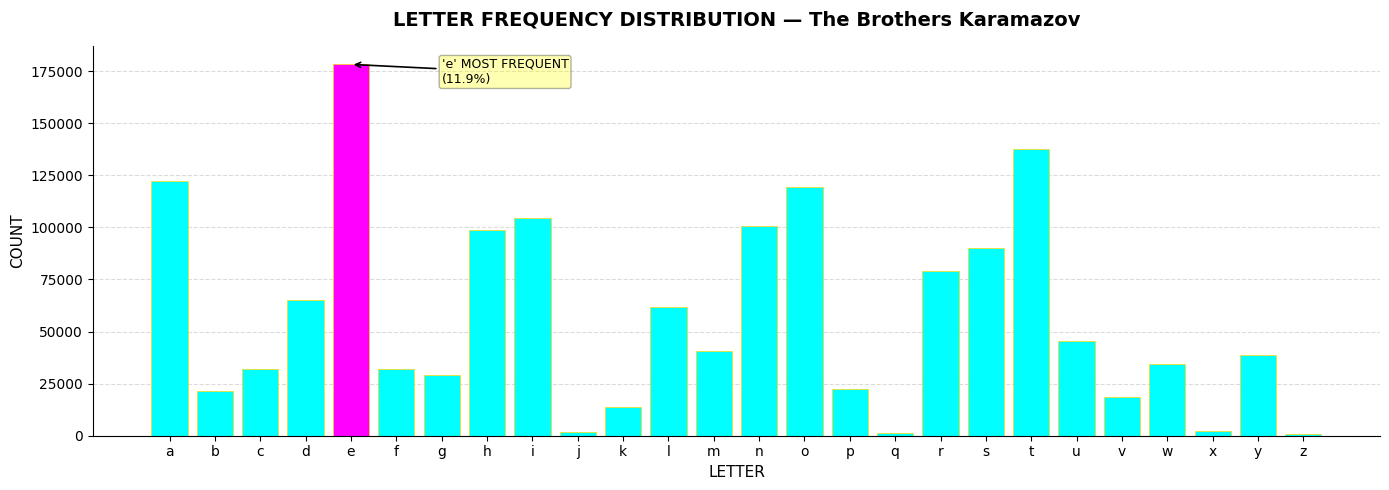

Saved: letter_frequencies.png


In [ ]:
# LETTER FREQUENCY VISUALIZATION
# GENERATING A BAR CHART OF LETTER DISTRIBUTIONS ACROSS THE FULL ALPHABET
# WHY:
# 1. VISUAL REPRESENTATION MAKES FREQUENCY PATTERNS IMMEDIATELY APPARENT
# 2. ALLOWS DIRECT COMPARISON AGAINST KNOWN ENGLISH LETTER DISTRIBUTIONS

# BUILDING ORDERED LISTS OF ALL 26 LETTERS AND THEIR COUNTS
# ORDER IS ALPHABETICAL (a–z) TO MATCH X-AXIS LAYOUT
letters = list(string.ascii_lowercase)
counts = [letterCounts[l] for l in letters]

# IDENTIFYING THE SINGLE MOST FREQUENT LETTER FOR VISUAL CALLOUT
# max() WITH key=letterCounts.get RETURNS THE LETTER (KEY) WITH HIGHEST COUNT (VALUE)
topLetter = max(letterCounts, key=letterCounts.get)

# BUILDING A COLOR LIST: HIGHLIGHT MOST FREQUENT LETTER IN MAGENTA
# ALL OTHER BARS USE CYAN TO CREATE OBVIOUS VISUAL CONTRAST
# WHY: DRAWS THE READER'S ATTENTION DIRECTLY TO THE DOMINANT LETTER
colors = ['magenta' if l == topLetter else 'cyan' for l in letters]

# INITIALIZING FIGURE AND AXES WITH WIDE ASPECT RATIO
# WHY: 26 BARS ACROSS THE ALPHABET FIT MORE NATURALLY IN A WIDE LAYOUT
fig, ax = plt.subplots(figsize=(14, 5))

# PLOTTING VERTICAL BAR CHART
# edgecolor='gold' CREATES SUBTLE SEPARATION BETWEEN ADJACENT BARS
ax.bar(letters, counts, color=colors, edgecolor='gold', linewidth=0.5)

# SETTING CHART TITLE AND AXIS LABELS
# f-STRING EMBEDS NOVEL TITLE FOR FULL TRACEABILITY
ax.set_title(f"LETTER FREQUENCY DISTRIBUTION — {novelTitle}",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("LETTER", fontsize=11)
ax.set_ylabel("COUNT", fontsize=11)

# PLACING GRIDLINES BEHIND BARS SO THEY DON'T OBSCURE DATA
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', alpha=0.45)
# REMOVING TOP AND RIGHT SPINES FOR A CLEANER, MODERN LOOK
# WHY: REDUCES CHART JUNK; FOCUSES ATTENTION ON DATA
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ADDING AN ANNOTATED ARROW CALLOUT TO THE MOST FREQUENT LETTER
# xy         - TIP OF THE ARROW (TOP OF THE TALLEST BAR)
# xytext     - TEXT LABEL POSITION (OFFSET TO AVOID OVERLAPPING THE BAR)
# bbox       - CREATES BOX SURROUNDING TEXT
# arrowprops - DEFINES ARROW STYLE AND COLOR
ax.annotate(
    f"'{topLetter}' MOST FREQUENT\n({letterProps[topLetter]*100:.1f}%)",
    xy=(letters.index(topLetter), letterCounts[topLetter]),
    xytext=(letters.index(topLetter) + 2, letterCounts[topLetter] * 0.95),
    bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.3),
    arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
    fontsize=9, color='black'
)

# APPLYING TIGHT LAYOUT TO PREVENT LABEL CLIPPING
plt.tight_layout()
# SAVING FIGURE TO DISK AT HIGH DPI FOR REPORT INCLUSION
# bbox_inches='tight' ENSURES NO LABELS ARE CUT OFF AT EDGES
plt.savefig('letter_frequencies.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: letter_frequencies.png")

**Interpretation:** The most frequent letter in The Brothers Karamazov is the letter 'e' (11.90% of all letters), consistent with known english frequency tables where e, t, a, o, i, n, are the top-ranking letter. The distribution closely mirrors the Zipf-like pattern expected for english prose; a small set of letters accounts for the majority of characters. Low frequency letters(q, x, z) appear rarely, as expected in a translated 19th century russian novel where names and vocabulary skew toward common latin-alphabet patterns.

---

**Themes (Words)**

In [ ]:
# WORD FREQUENCY COUNTING (POST-STOPWORD REMOVAL)
# BUILDING A RANKED LIST OF THE 40 MOST COMMON CONTENT WORDS
# WHY:
# 1. WORD FREQUENCY IS THE FOUNDATION OF BAG-OF-WORDS TEXT ANALYSIS
# 2. TOP WORDS REVEAL DOMINANT THEMES, CHARACTER NAMES, AND NARRATIVE FOCUS

def computeWordFreqs(tokens):
    """
    COUNTS WORD FREQUENCIES FROM A LIST OF FILTERED TOKENS USING Counter.
    ARGS:
        tokens (list[str]): POST-STOPWORD-REMOVAL TOKEN LIST
    RETURNS:
        Counter: MAPPING OF word -> count; CALL .most_common(k) TO GET SORTED RESULTS
    BIG-O: O(n) WHERE n = NUMBER OF TOKENS — SINGLE PASS THROUGH THE LIST
    """
    # Counter ITERATES THROUGH ALL TOKENS ONCE AND TALLIES OCCURRENCES
    # WHY: MORE EFFICIENT THAN A MANUAL DICT WITH CONDITIONAL UPDATES
    return Counter(tokens)

# APPLYING FREQUENCY COUNTER TO FULLY FILTERED TOKEN LIST
wordFreq = computeWordFreqs(cleanTokens)
# EXTRACTING TOP 40 MOST COMMON WORDS
# most_common(k) RETURNS A LIST OF (word, count) TUPLES IN DESCENDING ORDER
# BIG-O: O(wlogk) WHERE k = 40 — INTERNALLY USES A HEAP FOR PARTIAL SORT
top40  = wordFreq.most_common(40)
# TOTAL FILTERED TOKEN COUNT — USED AS DENOMINATOR FOR PROPORTIONS
totalWords = len(cleanTokens)
# PRINTING SUMMARY STATISTICS
print(f"TOTAL TOKENS (FILTERED): {totalWords:,}")
print(f"UNIQUE VOCAB:     {len(wordFreq):,}\n")
# PRINTING RANKED FREQUENCY TABLE WITH ALIGNED COLUMNS
# :<6    LEFT-JUSTIFIED IN 6-CHAR FIELD (RANK)
# :<22   LEFT-JUSTIFIED IN 22-CHAR FIELD (WORD)
# :<10   LEFT-JUSTIFIED IN 10-CHAR FIELD (COUNT)
print(f"{'RANK':<6} {'WORD':<22} {'COUNT':<10} {'PROPORTION'}")
print("─" * 50)
for rank, (word, count) in enumerate(top40, 1):
    # COMPUTING PROPORTION OF EACH WORD RELATIVE TO TOTAL FILTERED TOKENS
    # WHY: NORMALIZES COUNTS — USEFUL COMPARING TEXTS OF DIFFERENT LENGTHS
    print(f"{rank:<6} {word:<22} {count:<10,} {count/totalWords*100:.3f}%")

TOTAL TOKENS (FILTERED): 162,523
UNIQUE VOCAB:     13,330

RANK   WORD                   COUNT      PROPORTION
──────────────────────────────────────────────────
1      one                    1,546      0.951%
2      alyosha                1,177      0.724%
3      would                  1,097      0.675%
4      said                   993        0.611%
5      man                    843        0.519%
6      know                   842        0.518%
7      though                 830        0.511%
8      mitya                  815        0.501%
9      dont                   784        0.482%
10     come                   774        0.476%
11     father                 725        0.446%
12     ivan                   678        0.417%
13     time                   669        0.412%
14     like                   664        0.409%
15     could                  658        0.405%
16     even                   647        0.398%
17     go                     618        0.380%
18     see            

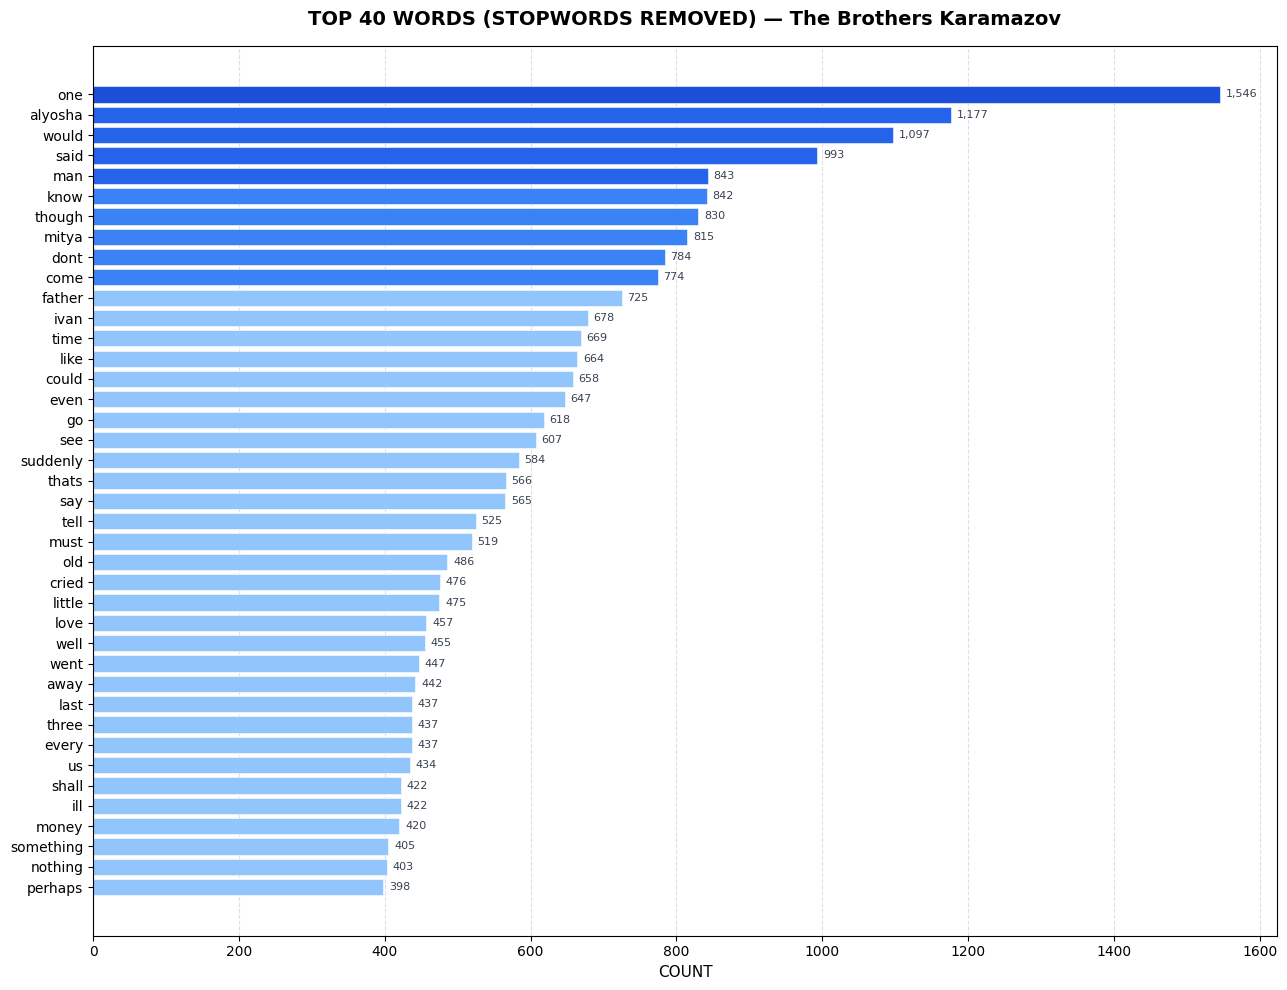

Saved: word_frequencies.png


In [ ]:
# WORD FREQUENCY VISUALIZATION — HORIZONTAL BAR CHART
# VISUALIZING THE 40 MOST FREQUENT CONTENT WORDS AS A RANKED BAR CHART
# WHY:
# 1. HORIZONTAL LAYOUT ACCOMMODATES WORD LABELS WITHOUT ROTATION
# 2. RANKED ORDERING MAKES RELATIVE FREQUENCY DIFFERENCES IMMEDIATELY VISIBLE

# UNPACKING TOP-40 LIST OF (word, count) TUPLES INTO SEPARATE SEQUENCES
# zip(*top40) TRANSPOSES A LIST OF PAIRS INTO TWO PARALLEL TUPLES
wordsTop40, countsTop40 = zip(*top40)
# INITIALIZING FIGURE — TALLER TO ACCOMMODATE 40 HORIZONTAL BARS
fig, ax = plt.subplots(figsize=(13, 10))
# BUILDING A COLOR PALETTE THAT DARKENS PROPORTIONALLY WITH RANK
#  RANK 1      : DARKEST BLUE  (#1D4ED8) — HIGHEST FREQUENCY
#  RANKS 2–5   : MEDIUM-DARK BLUE (#2563EB)
#  RANKS 6–10  : MEDIUM BLUE (#3B82F6)
#  RANKS 11–40 : LIGHTEST BLUE (#93C5FD)
# WHY: VISUAL ENCODING OF RANK REDUCES NEED TO READ EVERY LABEL
palette = ['#1D4ED8'] * 1 + ['#2563EB'] * 4 + ['#3B82F6'] * 5 + ['#93C5FD'] * 30

# PLOTTING HORIZONTAL BARS IN REVERSED ORDER SO RANK 1 APPEARS AT THE TOP
# list(reversed(...)) FLIPS BOTH SEQUENCES CONSISTENTLY
# WHY: NATURAL READING DIRECTION — HIGHEST VALUE FIRST
ax.barh(
    list(reversed(wordsTop40)),
    list(reversed(countsTop40)),
    color=list(reversed(palette)),
    edgecolor='white', linewidth=0.4
)
# SETTING TITLE AND AXIS LABEL
ax.set_title(f"TOP 40 WORDS (STOPWORDS REMOVED) — {novelTitle}",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("COUNT", fontsize=11)
# PLACING GRIDLINES BEHIND BARS
ax.set_axisbelow(True)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
# ADDING INLINE COUNT LABELS AT THE END OF EACH BAR
# WHY: ALLOWS EXACT VALUE READING WITHOUT REQUIRING GRIDLINE ESTIMATION
for i, (word, count) in enumerate(zip(reversed(wordsTop40), reversed(countsTop40))):
    ax.text(count + max(countsTop40) * 0.005, i, f"{count:,}",
            va='center', fontsize=8, color='#374151')

plt.tight_layout()
plt.savefig('word_frequencies.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: word_frequencies.png")

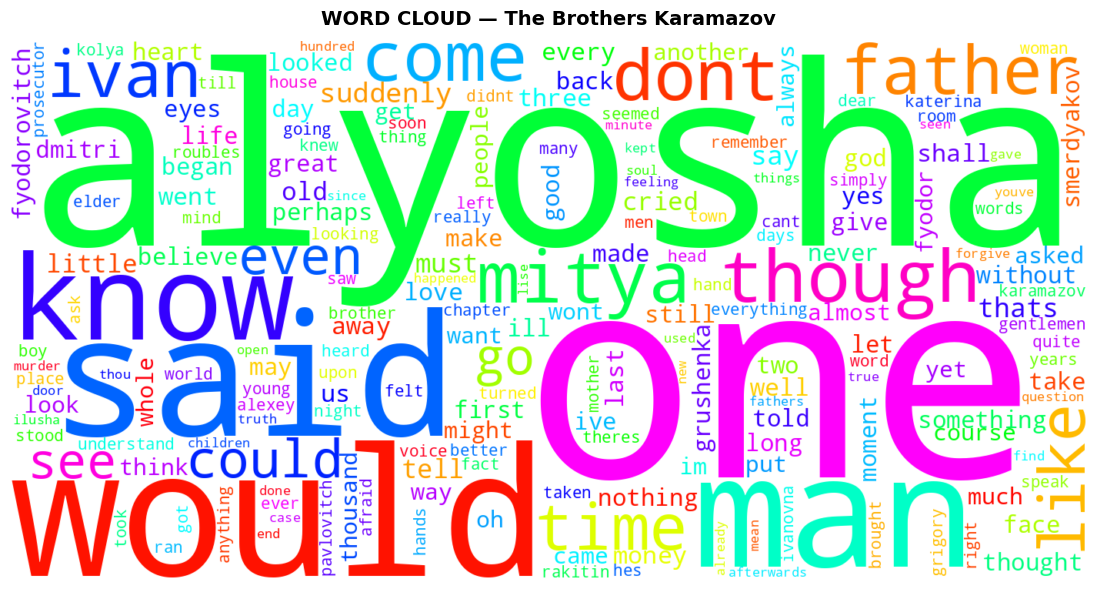

SAVED: word_cloud_words.png


In [ ]:
# WORD CLOUD VISUALIZATION
# GENERATING A WORD CLOUD WHERE FONT SIZE IS PROPORTIONAL TO WORD FREQUENCY
# WHY:
# 1. PROVIDES AN INTUITIVE QUALITATIVE SNAPSHOT OF THE MOST PROMINENT VOCABULARY
# 2. COMPLEMENTS THE BAR CHART BY EMPHASIZING RELATIVE SCALE AT A GLANCE

def generateWordCloud(freqDict, title, filename, colormap='Blues'):
    """
    GENERATES AND SAVES A WORD CLOUD FROM A WORD FREQUENCY DICTIONARY.
    FONT SIZE OF EACH WORD IS PROPORTIONAL TO ITS FREQUENCY.
    ARGS:
        freqDict (dict): WORD TO FREQUENCY MAPPING
        title    (str):  PLOT TITLE STRING
        filename (str):  OUTPUT .png FILENAME
        colormap (str):  MATPLOTLIB COLORMAP NAME FOR WORD COLORING
    RETURNS:
        None — DISPLAYS AND SAVES THE FIGURE TO DISK
    BIG-O: O(nlogn) WHERE n = UNIQUE VOCABULARY SIZE (INTERNAL LAYOUT SORT)
    """
    # CONFIGURING WORD CLOUD GENERATOR
    # width/height  - OUTPUT RESOLUTION IN PIXELS
    # max_words     - CAPS DISPLAYED VOCABULARY TO AVOID VISUAL CLUTTER
    # min_font_size - PREVENTS RARE WORDS FROM BEING RENDERED UNREADABLY SMALL
    # collocations=False - PREVENTS DUPLICATE BIGRAMS FROM APPEARING ALONGSIDE UNIGRAMS
    wc = WordCloud(
        width=1400, height=700,
        background_color='white',
        colormap=colormap,
        max_words=200,
        min_font_size=8,
        collocations=False
    ).generate_from_frequencies(freqDict)
    # generate_from_frequencies() ACCEPTS A {word: count} DICT DIRECTLY
    # WHY: MORE PRECISE THAN generate() WHICH RE-TOKENIZES A RAW STRING
    # RENDERING WORD CLOUD ONTO MATPLOTLIB FIGURE
    fig, ax = plt.subplots(figsize=(14, 6))
    # imshow() DISPLAYS THE CLOUD AS A RASTER IMAGE
    # interpolation='bilinear' -> SMOOTHS PIXEL EDGES FOR CLEANER APPEARANCE
    ax.imshow(wc, interpolation='bilinear')
    # DISABLING AXES — NO TICKS OR SPINES ARE MEANINGFUL FOR AN IMAGE PLOT
    ax.axis('off')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()


# CALLING WORD CLOUD GENERATOR WITH FULL FILTERED WORD FREQUENCY DICT
# dict(wordFreq) CONVERTS Counter OBJECT TO PLAIN DICT (REQUIRED BY WordCloud)
generateWordCloud(
    dict(wordFreq),
    f"WORD CLOUD — {novelTitle}",
    'word_cloud_words.png',
    colormap='gist_rainbow'
)
print("SAVED: word_cloud_words.png")


**Interpretation:** Our method `computeWordFreqs(tokens)` was used to compute the frequency of words from *Dostoevsky's novel*. The most frequent word from the novel was the word "one" occuring 1,546 times for over 0.591 % of the total words from the novel. Other common words involved the main characters "Alyosha" (1,177 times), "Mitya"(815 times), "Father"(725 times), and "Ivan"(678 times). Many of the words involved patterns that followed the theme of dysfunctionality within the main family, words such as "love"(457 times) and "cried" (476 times) explained the complicated feelings within the family. These word counts, coincide with the theme of the book which explored the dysfunctionality of the family from *The Brothers Karamazov*.






---

### **Phrase Patterns (N-grams)**

**N-gram Discussion**

The phrase patterns we decided to work on were the unigrams, bigrams, and
trigrams of our novel. For unigrams, since they are considered only single
words we were able to conduct our analysis with the `computeWordFreqs(tokens)`
method and found that most of the single words followed the pattern of the
first names of the titular characters from our novel.

For the bigrams, since they are pairs of consecutive words we used
`computeBigrams(tokens)` to find the most common two-word sequences. Character
full names dominated the top results — "fyodor pavlovitch" was the most
frequent bigram by a wide margin (254 occurrences), followed by the other
titular characters: "katerina ivanovna" and "dmitri fyodorovitch" (166 each),
and "alexey fyodorovitch" (109). The financial theme of the novel also surfaces
clearly, with "three thousand" (170) and "thousand roubles" (66) both cracking
the top 20. An interesting artifact of our preprocessing is "dont know" (139),
which appears because Dostoevsky's original text uses curly apostrophes (')
rather than straight apostrophes (') — our regex only protects straight
apostrophes, so "don't" loses its apostrophe and gets counted as two separate
forms. This is a known limitation of our rule-based approach.

Finally, for trigrams we used `computeTrigrams(tokens)` to find the most common
three-word sequences. The top result, "three thousand roubles" (44 occurrences),
is directly tied to the central plot of the novel — Fyodor Pavlovich Karamazov
is murdered over three thousand roubles, so it makes sense that this phrase
recurs throughout. Other currency-related trigrams like "two hundred roubles"
and "fifteen hundred roubles" (13 each) reinforce how central money is to the
narrative. The religious dimension of the novel also appears through "made sign
cross" (7), and the full name "pyotr alexandrovitch miusov" (7) now appears
correctly after our unicode normalization fixed what had previously been the
corrupted artifact "mi sov".

**Bigrams (2-grams)**

TOTAL UNIQUE BIGRAMS: 128,292

RANK   BIGRAM                              COUNT      PROPORTION
────────────────────────────────────────────────────────────
1      fyodor pavlovitch                   254        0.1563%
2      every one                           213        0.1311%
3      old man                             186        0.1144%
4      three thousand                      170        0.1046%
5      dmitri fyodorovitch                 166        0.1021%
6      katerina ivanovna                   166        0.1021%
7      dont know                           139        0.0855%
8      alexey fyodorovitch                 109        0.0671%
9      nikolay parfenovitch                97         0.0597%
10     pyotr ilyitch                       89         0.0548%
11     said alyosha                        88         0.0541%
12     young man                           81         0.0498%
13     father zossima                      79         0.0486%
14     madame hohlakov               

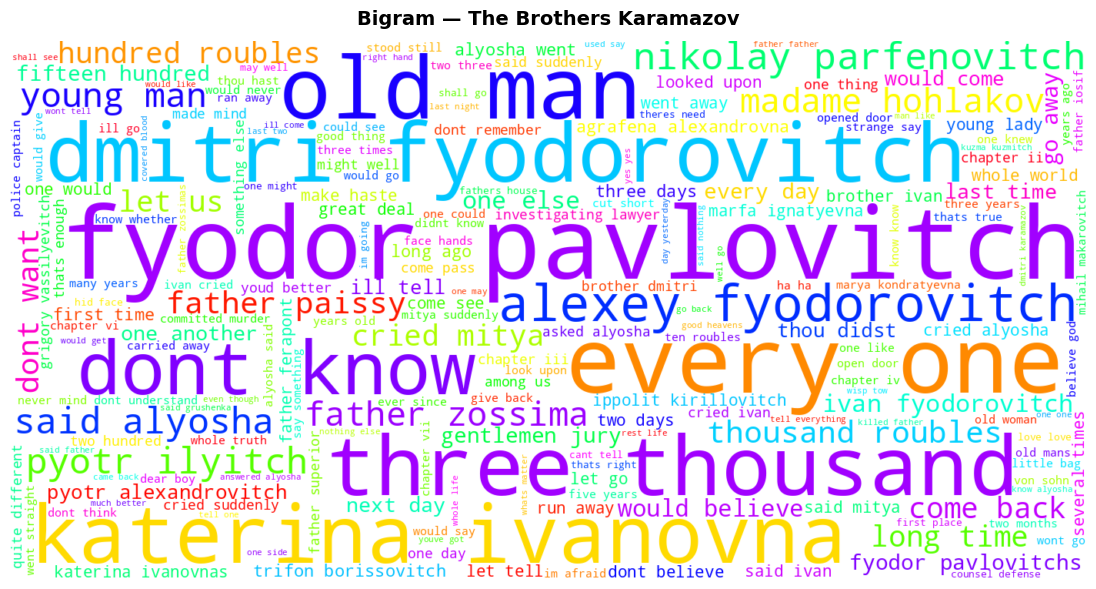

SAVED: word_cloud_bigrams.png


In [ ]:
# BIGRAM GENERATION USING SLIDING WINDOW APPROACH
# A BIGRAM IS A SEQUENCE OF TWO CONSECUTIVE TOKENS
# EXAMPLE: "data science is great" TO ["data science", "science is", "is great"]
# WHY:
# 1. CAPTURES CO-OCCURRENCE PATTERNS BETWEEN ADJACENT WORDS
# 2. REVEALS COMMON TWO-WORD PHRASES AND THEMATIC PAIRINGS IN THE TEXT

def computeBigrams(tokens):
    """
    GENERATES ALL BIGRAMS FROM A TOKEN LIST USING A SLIDING WINDOW OF SIZE 2
    AND RETURNS THEIR FREQUENCY COUNTS.
    ARGS:
        tokens (list[str]): CLEANED, FILTERED TOKEN LIST (POST-STOPWORD REMOVAL)
    RETURNS:
        Counter: MAPPING OF bigram_string -> count; {"ivan karamazov": 42}
    BIG-O: O(w) WHERE w = NUMBER OF TOKENS — SINGLE PASS VIA zip()
    """
    # SLIDING WINDOW: zip(tokens, tokens[1:]) PAIRS EACH TOKEN WITH ITS SUCCESSOR
    # JOINING TUPLE WITH SPACE PRODUCES A READABLE BIGRAM STRING
    # WHY: zip() IS MORE MEMORY-EFFICIENT THAN EXPLICIT INDEX LOOPING
    bigrams = [f"{a} {b}" for a, b in zip(tokens, tokens[1:])]
    return Counter(bigrams)

# APPLYING BIGRAM FUNCTION TO CLEANED TOKEN LIST
bigramCounts = computeBigrams(cleanTokens)
# EXTRACTING TOP 20 MOST FREQUENT BIGRAMS
# BIG-O: O(w log k) WHERE k=20 — heapq.nlargest INTERNALLY
top20Bigrams = bigramCounts.most_common(20)
# PRINTING RANKED BIGRAM FREQUENCY TABLE
print(f"TOTAL UNIQUE BIGRAMS: {len(bigramCounts):,}\n")
print(f"{'RANK':<6} {'BIGRAM':<35} {'COUNT':<10} {'PROPORTION'}")
print("─" * 60)
for rank, (bigram, count) in enumerate(top20Bigrams, 1):
    proportion = count / len(cleanTokens) * 100
    print(f"{rank:<6} {bigram:<35} {count:<10,} {proportion:.4f}%")
# Bigram Word Cloud
generateWordCloud(
    dict(bigramCounts),
    f"Bigram — {novelTitle}",
    'word_cloud_bigrams.png',
    colormap='gist_rainbow'
)
print("SAVED: word_cloud_bigrams.png")

**Trigrams (3-grams)**

TOTAL UNIQUE TRIGRAMS: 159,324

RANK   TRIGRAM                                       COUNT      PROPORTION
──────────────────────────────────────────────────────────────────────
1      three thousand roubles                        44         0.0271%
2      cried fyodor pavlovitch                       13         0.0080%
3      two hundred roubles                           13         0.0080%
4      fifteen hundred roubles                       13         0.0080%
5      hid face hands                                12         0.0074%
6      dont know whether                             12         0.0074%
7      dear alexey fyodorovitch                      10         0.0062%
8      father fyodor pavlovitch                      9          0.0055%
9      cried madame hohlakov                         9          0.0055%
10     fyodor pavlovitch karamazov                   8          0.0049%
11     like little child                             8          0.0049%
12     like fyodor pavlovitch 

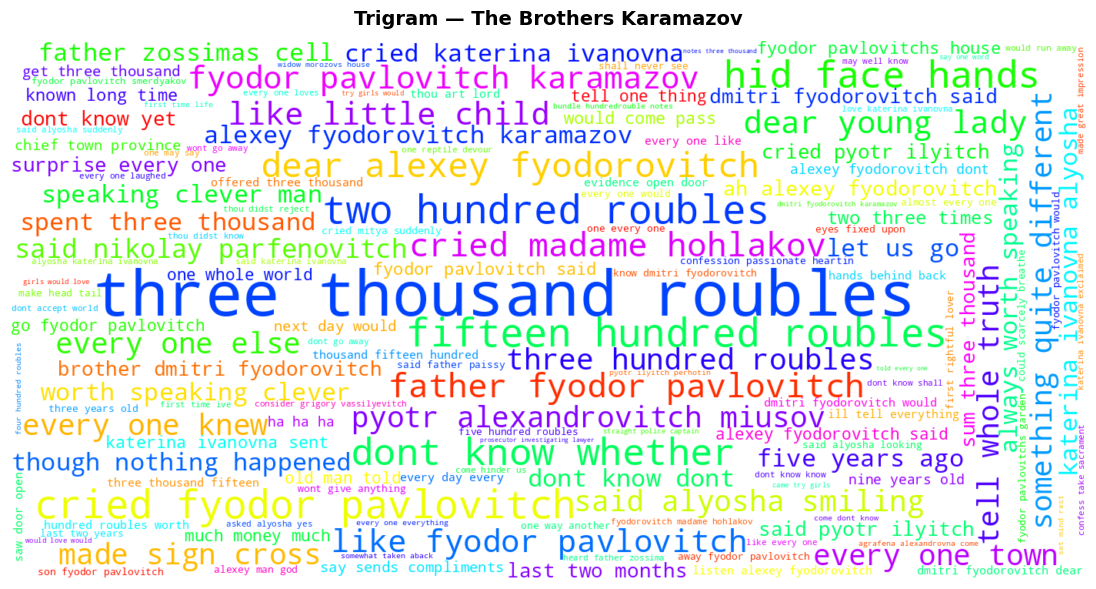

SAVED: word_cloud_trigrams.png


In [ ]:
# TRIGRAM GENERATION USING SLIDING WINDOW APPROACH
# A TRIGRAM IS A SEQUENCE OF THREE CONSECUTIVE TOKENS
# EXAMPLE: "data science is great" → ["data science is", "science is great"]
# WHY:
# 1. CAPTURES RICHER PHRASE STRUCTURE THAN BIGRAMS
# 2. SURFACES THREE-WORD EXPRESSIONS AND RECURRING NARRATIVE PATTERNS

def computeTrigrams(tokens):
    """
    GENERATES ALL TRIGRAMS FROM A TOKEN LIST USING A SLIDING WINDOW OF SIZE 3
    AND RETURNS THEIR FREQUENCY COUNTS.
    ARGS:
        tokens (list[str]): CLEANED, FILTERED TOKEN LIST (POST-STOPWORD REMOVAL)
    RETURNS:
        Counter: MAPPING OF trigram_string -> count, {"father ivan alyosha": 12}
    BIG-O: O(w) WHERE w = NUMBER OF TOKENS — SINGLE PASS VIA zip()
    """
    # SLIDING WINDOW OF SIZE 3: zip(tokens, tokens[1:], tokens[2:])
    # EACH ITERATION YIELDS A (word1, word2, word3) TUPLE
    # WHY: SAME EFFICIENT zip() PATTERN AS BIGRAMS, EXTENDED BY ONE POSITION
    trigrams = [f"{a} {b} {c}" for a, b, c in zip(tokens, tokens[1:], tokens[2:])]
    return Counter(trigrams)

# APPLYING TRIGRAM FUNCTION TO CLEANED TOKEN LIST
trigramCounts = computeTrigrams(cleanTokens)
# EXTRACTING TOP 20 MOST FREQUENT TRIGRAMS
top20Trigrams = trigramCounts.most_common(20)
# PRINTING RANKED TRIGRAM FREQUENCY TABLE
print(f"TOTAL UNIQUE TRIGRAMS: {len(trigramCounts):,}\n")
print(f"{'RANK':<6} {'TRIGRAM':<45} {'COUNT':<10} {'PROPORTION'}")
print("─" * 70)
for rank, (trigram, count) in enumerate(top20Trigrams, 1):
    proportion = count / len(cleanTokens) * 100
    print(f"{rank:<6} {trigram:<45} {count:<10,} {proportion:.4f}%")
# Trigram Word Cloud
generateWordCloud(
    dict(trigramCounts),
    f"Trigram — {novelTitle}",
    'word_cloud_trigrams.png',
    colormap='gist_rainbow'
)
print("SAVED: word_cloud_trigrams.png")

### Challenge: Sentence-Structure Metrics


For our challenge we display three sentence-structure metrics: average words
per sentence, common sentence starters, and sentence length distribution,
using the method `computeSentenceMetrics(text)` on the raw unprocessed text
of the Dostoevsky novel.

To split into sentences we used a regex on terminal punctuation (.  !  ?)
rather than an NLP library. We then stripped whitespace and filtered out
fragments of two words or fewer, which excludes chapter headings and other
Gutenberg boilerplate that would otherwise skew the results.

Word counts per sentence were computed with a simple whitespace split,
consistent with the rest of our tokenizer. For the average we summed all
word counts and divided by the total number of sentences.

For sentence starters, we first strip any leading non-letter characters —
quotation marks, dashes, and similar punctuation — using the regex pattern
`^[^a-zA-Z]+` before extracting the first word. Without this step,
Dostoevsky's heavy use of dialogue would cause opening quotation marks to
dominate the starters list rather than actual words, giving us a meaningless
result. After stripping, each starter is lowercased for consistent counting
so "The" and "the" are treated as the same token.

In [ ]:
def computeSentenceMetrics(text):
    """
    COMPUTES SENTENCE-LEVEL STRUCTURAL METRICS FROM RAW TEXT INCLUDING
    AVERAGE WORDS PER SENTENCE, SENTENCE LENGTH DISTRIBUTION, AND
    MOST COMMON SENTENCE STARTERS.
    ARGS:
        text (str): RAW NOVEL TEXT (BEFORE ANY PREPROCESSING)
    RETURNS:
        tuple:
            sents          (list[str]): LIST OF INDIVIDUAL SENTENCE STRINGS
            wordCounts     (list[int]): WORD COUNT PER SENTENCE
            avgWords       (float):     MEAN WORDS PER SENTENCE
            starterCounts  (Counter):   FREQUENCY OF FIRST WORDS
    BIG-O: O(n) WHERE n = NUMBER OF CHARACTERS — SINGLE REGEX PASS TO SPLIT,
           THEN O(s) WHERE s = NUMBER OF SENTENCES FOR DOWNSTREAM COUNTING
    """
    # SPLITTING RAW TEXT INTO SENTENCES ON TERMINAL PUNCTUATION
    # re.split() ON [.!?]+ HANDLES ELLIPSES AND MULTIPLE PUNCTUATION MARKS
    # WHY: SIMPLE RULE-BASED SPLITTING WITHOUT REQUIRING NLP LIBRARIES
    rawSents = re.split(r'[.!?]+', text)
    # STRIPPING WHITESPACE AND FILTERING OUT EMPTY OR NEAR-EMPTY FRAGMENTS
    # THRESHOLD OF > 2 WORDS EXCLUDES HEADERS, PAGE NUMBERS, AND ARTIFACTS
    # WHY: GUTENBERG FILES CONTAIN CHAPTER HEADINGS THAT ARE NOT TRUE SENTENCES
    sents = [s.strip() for s in rawSents if len(s.split()) > 2]
    # COMPUTING WORD COUNT FOR EACH SENTENCE
    # str.split() ON DEFAULT WHITESPACE IS CONSISTENT WITH TOKENIZER BEHAVIOR
    wordCounts = [len(s.split()) for s in sents]
    # MEAN WORDS PER SENTENCE
    avgWords = sum(wordCounts) / len(wordCounts)
    # EXTRACTING FIRST WORD OF EACH SENTENCE AS THE SENTENCE STARTER
    # STRIPPING LEADING NON-LETTER CHARACTERS (QUOTATION MARKS, DASHES)
    # BEFORE PULLING THE FIRST WORD — PREVENTS PUNCTUATION ARTIFACTS
    # WHY: DOSTOEVSKY'S DIALOGUE-HEAVY TEXT MEANS MANY SENTENCES START WITH
    #      AN OPENING QUOTATION MARK BEFORE THE FIRST ACTUAL WORD
    starters = [
        # LIST COMPREHENSION BUILDS A LIST BY RUNNING SAME OPERATION ON EVERY SENTENCE s IN sents; WORKS LIKE A FOR LOOP WITH IF STATEMENT
        re.sub(r"^[^a-zA-Z]+", "", s).split()[0].lower()
        for s in sents
        if re.sub(r"^[^a-zA-Z]+", "", s).split()
    ]
    starterCounts = Counter(starters)

    return sents, wordCounts, avgWords, starterCounts

In [ ]:
sents, wordCounts, avgWords, starterCounts = computeSentenceMetrics(rawText)

# SUMMARY STATISTICS
print("SENTENCE STRUCTURE METRICS")
print("─" * 40)
print(f"  TOTAL SENTENCES:   {len(sents):>10,}")
print(f"  AVERAGE WORDS/SENTENCE: {avgWords:>10.2f}")
print(f"  SHORTEST SENTENCE:  {min(wordCounts):>10,}")
print(f"  LONGEST SENTENCE:   {max(wordCounts):>10,}")
print(f"  MEDIAN SENTENCE LENGTH:     {sorted(wordCounts)[len(wordCounts)//2]:>10,}")

# TOP 10 SENTENCE STARTERS
print("\nTOP 10 SENTENCE STARTERS:")
print(f"{'RANK':<6} {'WORD':<20} {'COUNT'}")
print("─" * 35)
for rank, (word, count) in enumerate(starterCounts.most_common(10), 1):
    print(f"{rank:<6} {word:<20} {count:,}")

# LENGTH DISTRIBUTION BUCKETS
# GROUPING SENTENCE LENGTHS INTO BUCKETS FOR TABULAR DISPLAY
buckets = {
    "1-5 words":    sum(1 for w in wordCounts if 1  <= w <= 5),
    "6-15 words":   sum(1 for w in wordCounts if 6  <= w <= 15),
    "16-30 words":  sum(1 for w in wordCounts if 16 <= w <= 30),
    "31-50 words":  sum(1 for w in wordCounts if 31 <= w <= 50),
    "51+ words":    sum(1 for w in wordCounts if w  >= 51),
}
print("\nSENTENCE LENGTH DISTRIBUTION:")
print(f"{'BUCKET':<18} {'COUNT':<10} {'PROPORTION'}")
print("─" * 40)
for bucket, cnt in buckets.items():
    print(f"{bucket:<18} {cnt:<10,} {cnt/len(wordCounts)*100:.1f}%")

SENTENCE STRUCTURE METRICS
────────────────────────────────────────
  TOTAL SENTENCES:       24,294
  AVERAGE WORDS/SENTENCE:      14.54
  SHORTEST SENTENCE:           3
  LONGEST SENTENCE:          163
  MEDIAN SENTENCE LENGTH:             11

TOP 10 SENTENCE STARTERS:
RANK   WORD                 COUNT
───────────────────────────────────
1      i                    2,237
2      he                   2,030
3      and                  1,358
4      but                  1,269
5      the                  1,155
6      you                  745
7      it                   563
8      she                  501
9      what                 430
10     it’s                 315

SENTENCE LENGTH DISTRIBUTION:
BUCKET             COUNT      PROPORTION
────────────────────────────────────────
1-5 words          4,503      18.5%
6-15 words         11,614     47.8%
16-30 words        5,987      24.6%
31-50 words        1,796      7.4%
51+ words          394        1.6%


**Interpretation of Results**

After computing our sentence structure metrics for *The Brothers Karamazov
by Fyodor Dostoevsky (tr. Constance Garnett)*, we found the following results:

The top sentence starters were "i" (2,237), "he" (2,030), "and" (1,358),
and "but" (1,269). The dominance of first and third person pronouns confirms
what the word frequency analysis already suggested — this is a deeply
character-driven, dialogue-heavy novel. The high counts for "and" and "but"
are also telling: Dostoevsky frequently opens sentences with coordinating
conjunctions, which gives his prose a spoken, stream-of-consciousness quality
that mirrors his characters' emotional states. Moreover, "you" at rank 6 (745) further reinforces the conversational nature of the text.

As for the sentence length distribution, the novel contains 24,294 sentences
with an average of 14.54 words per sentence, a median of 11, a shortest of 3,
and a longest of 163. The distribution is right-skewed: the 6–15 word bucket
accounts for nearly half of all sentences (47.8%), and sentences of 30 words
or fewer make up over 90% of the total. The small tail of 51+ word sentences
(1.6%) represents Dostoevsky's occasional long philosophical passages, which
stand out as outliers against an otherwise generally conversational average sentence length.

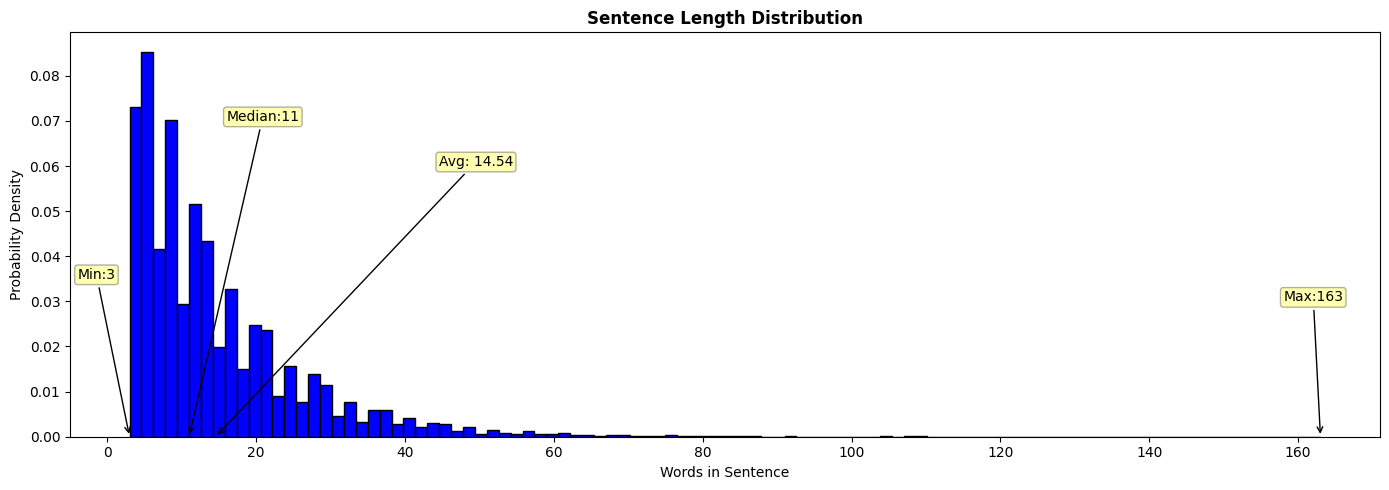

In [ ]:
# SENTENCE STRUCTURE HISTOGRAM

# Set minimum word counts
minWC = min(wordCounts)

# Set maximum word counts
maxWC = max(wordCounts)


# Set median word counts
medWC = sorted(wordCounts)[len(wordCounts)//2]

# Create a figure for the plots
fig, ax = plt.subplots(figsize=(14,5))


# Title For Histogram
ax.set_title("Sentence Length Distribution",fontweight="bold")
# Title for X-Label
ax.set_xlabel('Words in Sentence')
# Title for Y-Label
ax.set_ylabel('Probability Density')
# Constructing histogram plot
ax.hist(wordCounts, bins=100, density=True,
                histtype='bar', color='blue', edgecolor='black')


# ADDING AN ANNOTATED ARROW CALLOUT TO THE MINIMUM WORDS IN SENTENCE
# xy         - TIP OF THE ARROW (TOP OF THE TALLEST BAR)
# xytext     - TEXT LABEL POSITION (OFFSET TO AVOID OVERLAPPING THE BAR)
# bbox       - CREATES BOX SURROUNDING TEXT
# arrowprops - DEFINES ARROW STYLE AND COLOR
ax.annotate(f'Min:{minWC}',xy=(minWC,0), color='black',
               xytext=(minWC-7,0.035),
               bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.3),
               arrowprops={"arrowstyle": "->"})

# ADDING AN ANNOTATED ARROW CALLOUT TO THE AVERAGE WORDS IN SENTENCE
# xy         - TIP OF THE ARROW (TOP OF THE TALLEST BAR)
# xytext     - TEXT LABEL POSITION (OFFSET TO AVOID OVERLAPPING THE BAR)
# bbox       - CREATES BOX SURROUNDING TEXT
# arrowprops - DEFINES ARROW STYLE AND COLOR
ax.annotate(f'Avg: {avgWords:.2f}',xy=(avgWords,0), color='black',
               xytext=(avgWords+30,0.06),
               bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.3),
               arrowprops={"arrowstyle": "->"})

# ADDING AN ANNOTATED ARROW CALLOUT TO THE MEDIUM WORDS IN SENTENCE
# xy         - TIP OF THE ARROW (TOP OF THE TALLEST BAR)
# xytext     - TEXT LABEL POSITION (OFFSET TO AVOID OVERLAPPING THE BAR)
# bbox       - CREATES BOX SURROUNDING TEXT
# arrowprops - DEFINES ARROW STYLE AND COLOR
ax.annotate(f'Median:{medWC}',xy=(medWC,0), color='black',
               xytext=(medWC+5,0.07),
               bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.3),
               arrowprops={"arrowstyle": "->"})


# ADDING AN ANNOTATED ARROW CALLOUT TO THE MAXIMUM WORDS IN SENTENCE
# xy         - TIP OF THE ARROW (TOP OF THE TALLEST BAR)
# xytext     - TEXT LABEL POSITION (OFFSET TO AVOID OVERLAPPING THE BAR)
# bbox       - CREATES BOX SURROUNDING TEXT
# arrowprops - DEFINES ARROW STYLE AND COLOR
ax.annotate(f'Max:{maxWC}',xy=(maxWC,0), color='black',
               xytext=(maxWC-5,0.03),
               bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.3),
               arrowprops={"arrowstyle": "->"})

# APPLYING TIGHT LAYOUT TO PREVENT LABEL CLIPPING
fig.tight_layout()

plt.show()